# Случайный лес

Цель этого ноутбука &mdash; знакомство со случайными лесами, с их параметрами и свойствами. В ноутбуке будут рассмотрены примеры применения случайного леса для решения задач классификации и регрессии.

In [ ]:
import copy
import random
import warnings
import os

import numpy as np
import pandas as pd
from pandas.io.formats.style import Styler
import scipy.stats as sps

from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns
from tqdm.notebook import tqdm
from typing import Tuple, Optional, Any, Dict, List, Callable, Union, Sequence

from sklearn import datasets
from sklearn import metrics
from sklearn.metrics import accuracy_score, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator

import graphviz

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.4)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Введение

### 1.0 Вспомогательные функции

Напишем вспомогательные функции для удобного сравнения метрик в табличке, позже они нам пригодятся.

In [ ]:
REGRESSION_METRICS = {
    "RMSE": root_mean_squared_error,
    "MAE": mean_absolute_error,
    "MAPE": mean_absolute_percentage_error,
    "r2-score": r2_score,
}

def evaluate_regression(
    model_name: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    metrics_df: pd.DataFrame,
    prefix: str = "",
    metrics_dict: Dict[str, Any] = REGRESSION_METRICS,
) -> None:
    """
    Универсальная функция для оценки качества в задаче регрессии.
    Считаются метрики MSE, MAE, MAPE, R2-score.

    Параметры:
    - model_name (str): имя модели
    - y_true (np.ndarray): истинные значения таргета
    - y_pred (np.ndarray): предсказания модели
    - metrics_df (pd.DataFrame): датафрейм для записи значений метрик
    """

    for metric_name, metric_function in metrics_dict.items():
        metrics_df.loc[model_name, prefix + metric_name] = metric_function(y_true, y_pred)

def highlight_best(series: pd.Series) -> List[str]:
    """
    Подсвечивает лучшие значения в столбце:
    - минимальные для времени;
    - максимальные для метрик.
    Игнорирует столбец 'Модель' и строковые 'nan'.

    Возвращает:
    - Список CSS-стилей для каждой ячейки.
    """
    # if series.name == 'Модель':
    #     return [''] * len(series)

    # Преобразование к числам, замена строковых 'nan'
    try:
        numeric_series = pd.to_numeric(series.replace(["nan", "NaN"], np.nan))
    except Exception:
        return [''] * len(series)

    if numeric_series.isnull().all():
        return [''] * len(series)

    # Выбор лучшего значения
    min_is_better = any(series.name.endswith(m) for m in ["RMSE", "MAE", "MAPE"])
    best_value = numeric_series.min() if min_is_better else numeric_series.max()
    return [
        'background-color: lightgreen' if val == best_value else ''
        for val in numeric_series
    ]

def visualize_metric_df(
    df: pd.DataFrame,
    precision: int = 4
) -> pd.io.formats.style.Styler:
    """
    Визуализирует таблицу метрик с округлением, чёрными рамками и подсветкой лучших значений.

    Параметры:
    - df: DataFrame с метриками
    - precision: количество знаков после запятой

    Возвращает:
    - pandas Styler: стилизованная таблица
    """
    df_rounded = df.copy()
    numeric_cols = df_rounded.select_dtypes(include=["float64", "int64"]).columns

    df_rounded[numeric_cols] = df_rounded[numeric_cols].astype(float).round(precision)
    for col in numeric_cols:
        df_rounded[col] = df_rounded[col].apply(lambda x: f"{x:.{precision}f}")

    return (
        df_rounded
        .style
        .set_table_styles([{
            "selector": "td, th",
            "props": [("border", "1px solid black")]
        }])
        .apply(highlight_best, axis=0)
    )


Посмотрим как они работают.

In [ ]:
metrics_df = pd.DataFrame()

evaluate_regression('Тестовая модель v1', 1 + np.random.random(100), 1 + np.random.random(100), metrics_df)
evaluate_regression('Тестовая модель v2', 1 + np.random.random(100), 1 + np.random.random(100), metrics_df)
visualize_metric_df(metrics_df)

,RMSE,MAE,MAPE,r2-score
Тестовая модель v1,0.4235,0.3541,0.2532,-1.0466
Тестовая модель v2,0.4559,0.3871,0.2698,-1.4381


### 1.1 Датасет

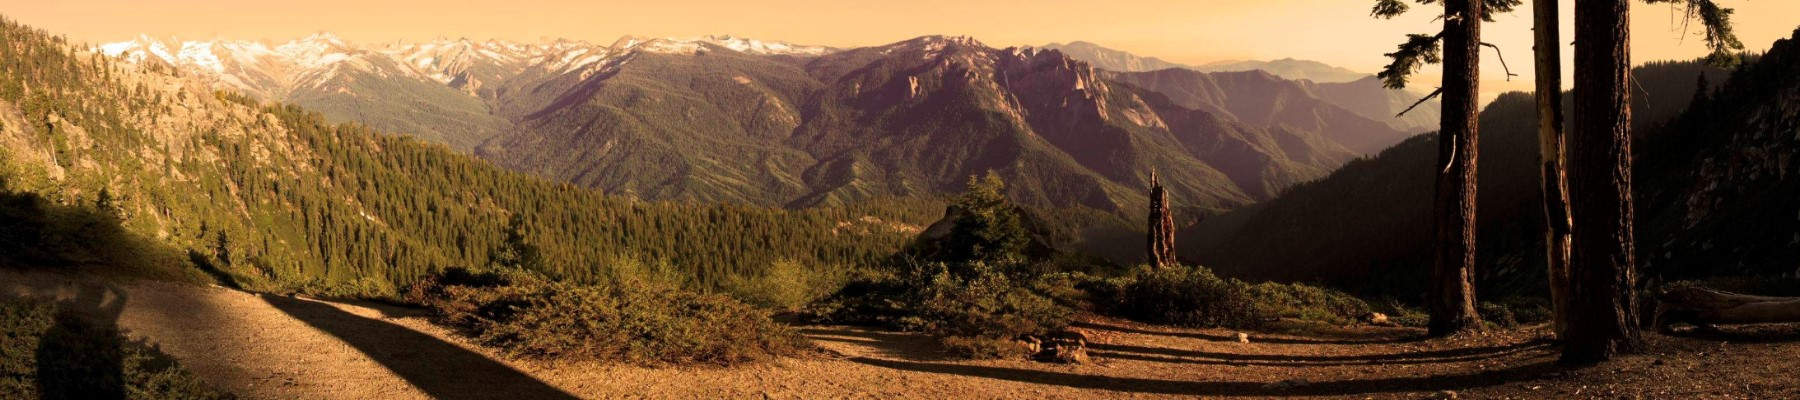

Рассмотрим датасет [**California Housing Prices**](https://www.kaggle.com/datasets/camnugent/california-housing-prices). Он содержит данные о стоимости жилья в Калифорнии, собранные на основе переписи населения США 1990 года. Задача заключается в анализе факторов, влияющих на цену домов, и в построении модели, которая способна предсказывать их рыночную стоимость.

Каждая строка датасета соответствует отдельному району (housing block) и описывается рядом числовых признаков:

1. **Median Income** — медианный доход жителей района (в десятках тысяч долларов)
2. **Housing Median Age** — медианный возраст жилых домов (в годах)
3. **Total Rooms** — общее количество комнат
4. **Total Bedrooms** — общее количество спален
5. **Population** — численность населения района
6. **Households** — количество домохозяйств
7. **Latitude** — географическая широта
8. **Longitude** — географическая долгота
9. **Ocean proximity** — близость к океану или морю

Целевая переменная — `Median House Value` (медианная стоимость дома в районе), измеряемая в долларах США.

Наша задача будет в предсказании `Median House Value`.

In [ ]:
import kagglehub

# Скачиваем датасет из kaggle
path = kagglehub.dataset_download("camnugent/california-housing-prices")
data = pd.read_csv(os.path.join(path, "housing.csv"))
data.head()

Using Colab cache for faster access to the 'california-housing-prices' dataset.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Посмотрим на информацию о датасете.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


В признаке `total_bedrooms` есть пропуски, но их немного, поэтому далее просто удалим строчки с пропусками.

Также видим, что признак `ocean_proximity` не числовой, посмотрим какие значения он может принимать.

In [ ]:
# Удаляем пропуски
data = data[~data.isna().any(axis=1)]

# Уникальные значения признака ocean_proximity
data["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

Признак `ocean_proximity` принимает всего 5 уникальных значений, которые можно упорядочить по близости к морю следующим образом:
1. ISLAND
2. NEAR OCEAN
3. NEAR BAY
4. <1H OCEAN
5. INLAND

Поскольку это порядковый признак, просто переведем его в числа, соответствующие индексу в упорядоченном ряду.

In [ ]:
ocean_proximity_values = ["ISLAND", "NEAR OCEAN", "NEAR BAY", "<1H OCEAN", "INLAND"]
data["ocean_proximity_num"] = data["ocean_proximity"].apply(lambda value: ocean_proximity_values.index(value))

Остается разделить данные на train и test выборки, и можно будет приступать к обучению моделей.

In [ ]:
houses_X = data.drop(columns=["median_house_value", "ocean_proximity"])
houses_y = data["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(
    houses_X, houses_y, test_size=0.2, random_state=RANDOM_STATE
)

houses_X.shape, houses_y.shape

((20433, 9), (20433,))

### 1.2 Обучаем модели

Посмотрим, какое качество дает решающее дерево разной глубины на этих данных.

In [ ]:
# Создадим табличку для хранения метрик
houses_metrics_df = pd.DataFrame()

# Переберем несколько глубин
for max_depth in [10, 12, 15]:
    single_tree = DecisionTreeRegressor(max_depth=max_depth, random_state=RANDOM_STATE)
    single_tree.fit(X_train, y_train)

    name = f'Решающее дерево глубиной {max_depth}'
    evaluate_regression(name, y_test, single_tree.predict(X_test),
                        houses_metrics_df, prefix='test_')
    evaluate_regression(name, y_train, single_tree.predict(X_train),
                        houses_metrics_df, prefix='train_')

visualize_metric_df(houses_metrics_df)

,test_RMSE,test_MAE,test_MAPE,test_r2-score,train_RMSE,train_MAE,train_MAPE,train_r2-score
Решающее дерево глубиной 10,61298.3282,40475.3533,0.2180,0.7252,47444.5182,31870.7199,0.1782,0.8299
Решающее дерево глубиной 12,61795.3098,39639.4205,0.2103,0.7208,37786.9526,24178.2134,0.1374,0.8921
Решающее дерево глубиной 15,65370.7652,41016.2934,0.2188,0.6875,24131.2113,13263.0676,0.0777,0.9560


Также посмотрим на линейную регрессию.

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

evaluate_regression('Линейная регрессия', y_test, lin_reg.predict(X_test), houses_metrics_df, prefix='test_')
evaluate_regression('Линейная регрессия', y_train, lin_reg.predict(X_train), houses_metrics_df, prefix='train_')
visualize_metric_df(houses_metrics_df)

,test_RMSE,test_MAE,test_MAPE,test_r2-score,train_RMSE,train_MAE,train_MAPE,train_r2-score
Решающее дерево глубиной 10,62780.4881,41291.6966,0.2221,0.7118,47248.4848,31811.5482,0.1781,0.8313
Решающее дерево глубиной 12,63466.3449,40325.4477,0.2140,0.7055,37572.0820,24002.7801,0.1370,0.8934
Решающее дерево глубиной 15,66404.7386,41485.1096,0.2225,0.6775,23435.4456,12899.4749,0.0762,0.9585
Линейная регрессия,69699.1370,50950.1022,0.2964,0.6448,69190.6092,50342.1788,0.2977,0.6383


MAPE больше 21% звучит довольно много. Посмотрим на зависимость таргета от остальных признаков и попробуем понять, почему текущие методы справляются не очень хорошо.

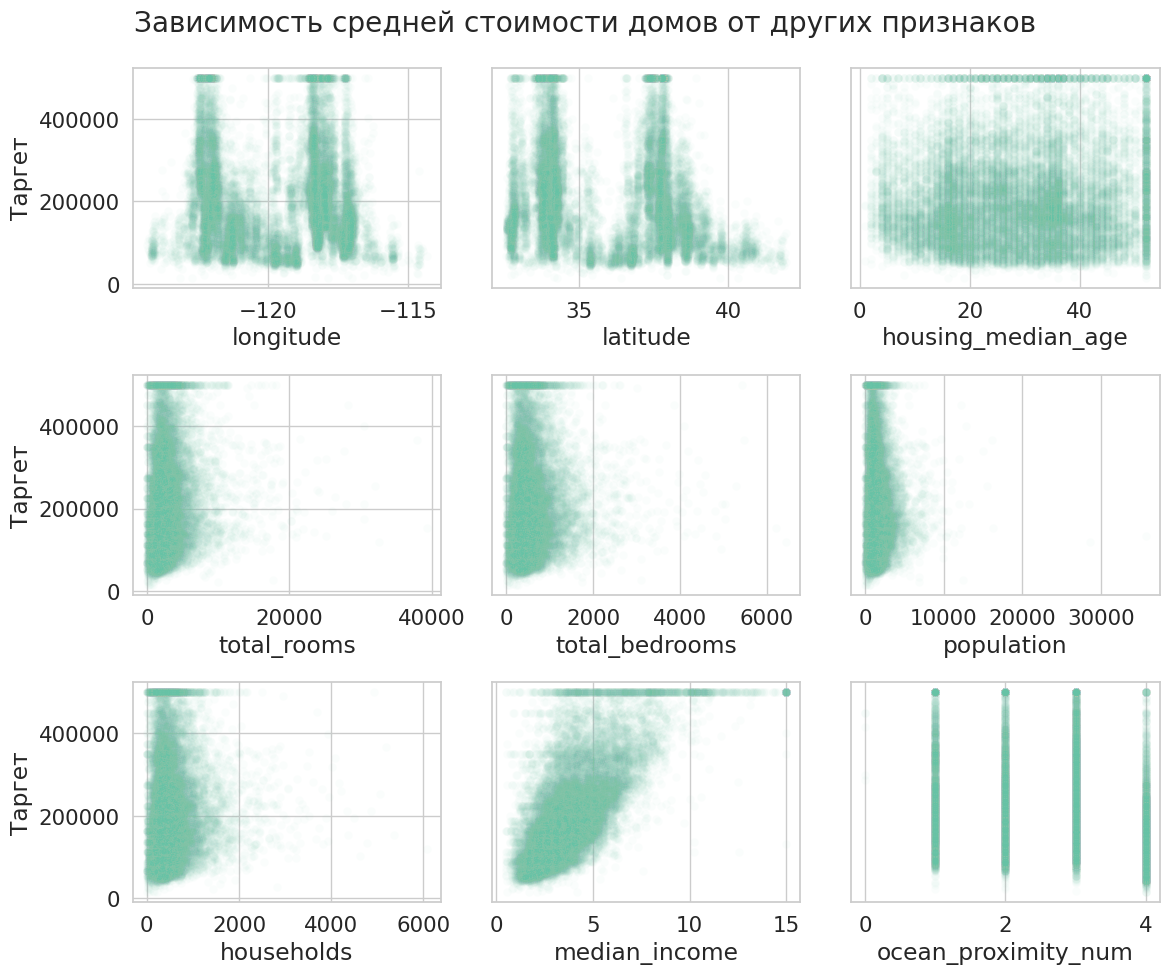

In [ ]:
plt.figure(figsize=(12, 10))
plt.suptitle(f'Зависимость средней стоимости домов от других признаков')

for i, feature in enumerate(houses_X.columns):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(x=houses_X[feature], y=houses_y, alpha=0.03)
    plt.xlabel(feature)
    if i % 3 != 0:
        plt.ylabel(None)
        plt.yticks([])
    else:
        plt.ylabel('Таргет')

plt.tight_layout()
plt.show()

Отдельно посмотрим на зависимость цены сразу от двух параметров: долготы и широты. Воспользуемся `plotly` для наложения точек на реальную карту местности.

In [ ]:
fig = px.scatter_map(
    houses_X,
    lat="latitude",
    lon="longitude",
    color=houses_y,
    color_continuous_scale="Viridis",
    size_max=8,
    zoom=5,
    opacity=0.6,
    height=600,
    width=900,
)

fig.update_layout(
    mapbox_style="open-street-map",   # стиль карты ("open-street-map", "carto-darkmatter", "carto-positron" и др.)
    coloraxis_colorbar=dict(title="Средняя цена домов"),
    title="Средняя цена домов в зависимости от локации"
)

fig.show()

Как видно, зависимости и близко не линейные, поэтому **линейная регрессия** ожидаемо работает плохо на этих данных.

Что касается **решающего дерева**, то тут есть два основных случая:

- ***Неглубокие деревья***

  Такие деревья слишком "грубые": они не смогут захватить сложные пересечения признаков. Поскольку разные признаки влияют по-разному, и влияние часто проявляется в сочетании (“если доход высокий и район ближе к океану и дома новые и ...”), неглубокое дерево просто не сможет выделить большое количество таких узких условий.

  Также признаки вроде широты/долготы (“latitude”, “longitude”) создают очень сложные географические паттерны: где-то цены высокие, где-то низкие, но нет простой пороговой зависимости “если latitude > X, то цена высокая”. Даже береговую линию не получится задать небольшим количеством простых условий, так как она не параллельна широте или долготе. То есть даже эти 2 географических признака уже требуют довольно глубокое дерево.

- ***Глубокие деревья***

  Если позволить дереву стать очень глубоким, оно сможет выделять множество “регионов” в пространстве признаков и, тем самым, аппроксимировать многие детали. Но при этом растёт риск переобучения: дерево будет “запоминать” шум, выбросы, случайные погрешности данных, не являющиеся общими закономерностями. В листьях такого дерева будет очень мало элементов обучающей выборки, поэтому его обобщающая способность снизится.

  Оно может построить ветки, очень специфичные для небольших подмножеств данных — такие ветки будут хороши на тренировочных данных, но будут плохо работать на новых примерах.

### 1.2 Синтетические данные

Проиллюстрируем эту проблему на синтетических данных, визуализировав предсказания линейной регрессии и решающего дерева. Будем приближать зашумленную функцию $\sin \left(3 x\right) - x \cos^2\left(7 x\right) + x^2 \sin \left(5 x\right), \hspace{3mm} x \in \left[-2, 2\right]$.

In [ ]:
def f(x):
    """Целевая функция"""
    return np.sin(3 * x) - x * np.cos(7 * x)**2 + x**2 * np.sin(5 * x)

Создадим сетку для визуализации истинной зависимости, а также сгенерируем тренировочную выборку из 3000 зашумленных точек.

In [ ]:
# Сетка точных значений
x_grid = np.linspace(-2, 2, 1000)
y_grid_values = f(x_grid)

# Тренировочная выборка
train_size = 3000

np.random.seed(RANDOM_STATE)
x_train_synthetic = np.random.uniform(low=-2, high=2, size=(train_size, 1))
y_train_synthetic = f(x_train_synthetic)[:, 0] + np.random.normal(loc=0, scale=0.5, size=train_size)

Создадим табличку для сохранения и сравнения метрик

In [ ]:
synthetic_metrics_df = pd.DataFrame()

Изобразим график целевой функции и тренировочную выборку. Переиспользуем функцию из предыдущего семинара, добавив в запись метрик в табличку.

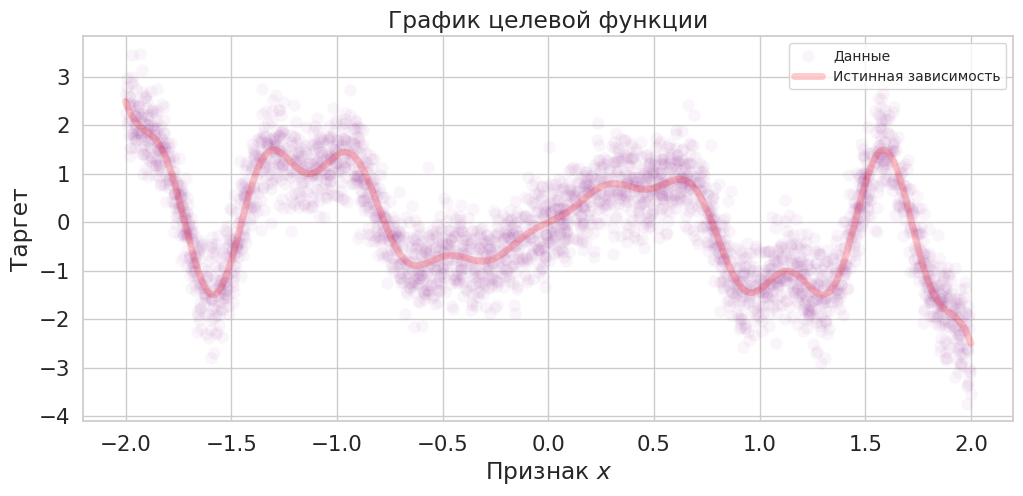

In [ ]:
def plot_regression_results(
    X: np.ndarray,
    y: np.ndarray,
    X_grid: np.ndarray,
    f_grid: np.ndarray,
    model_preds: Optional[Dict[str, np.ndarray]] = None,
    title: str = "Сравнение предсказаний моделей",
    fig: Optional[plt.Figure] = None,
) -> None:
    """
    Отображает результаты линейной регрессии вместе
    с истинной зависимостью и данными.

    Параметры:
    X (np.ndarray): Входные данные.
    y (np.ndarray): Целевые значения.
    X_grid (np.ndarray): Сетка для отображения исходной зависимости.
    f_grid (np.ndarray): Значения истинной зависимости на сетке X_grid.
    models (Optional[Dict[str, Optional[Any]]]): Словарь, где ключи — подписи, а
        значения — модели, реализующие метод predict (могут быть None).
    features_grid_list (Optional[List[np.ndarray]]): Список массивов сетки признаков
        для каждой модели.
    title (str): Заголовок графика (по умолчанию "Сравнение предсказаний моделей").
    fig (Optional[plt.Figure]): Фигура для отображения графика (по умолчанию None).
    """
    if fig == None:
      fig = plt.figure(figsize=(12, 5))

    ax = fig.add_subplot(1,1,1)

    # Отображение данных
    sns.scatterplot(
        x=X.reshape(-1), y=y.reshape(-1), label="Данные", alpha=0.04, s=80, color="purple", ax=ax
    )

    # Истинная зависимость
    sns.lineplot(
        x=X_grid,
        y=f_grid,
        label="Истинная зависимость",
        linewidth=5,
        alpha=0.2,
        ax=ax,
        color="red",
    )

    # Проверяем, переданы ли модели и соответствующие данные
    if model_preds:
        for (label, y_pred) in model_preds.items():
            evaluate_regression(label, f_grid, y_pred.reshape(-1), synthetic_metrics_df)
            sns.lineplot(
                x=X_grid,
                y=y_pred.reshape(-1),
                label=f"{label}",
                linewidth=3,
                alpha=0.9,
                ax=ax,
            )

    ax.set_title(title)
    ax.set_xlabel("Признак $x$"), ax.set_ylabel("Таргет")
    ax.legend(fontsize=10)

plot_regression_results(x_train_synthetic, y_train_synthetic, x_grid, y_grid_values, title='График целевой функции')

Обучим линейную регрессию и несколько решающих деревьев с разной глубиной

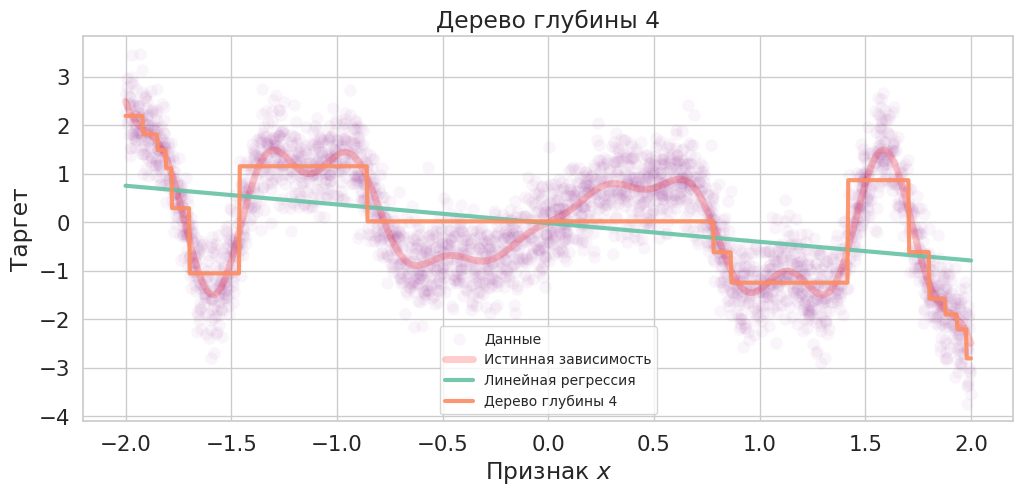

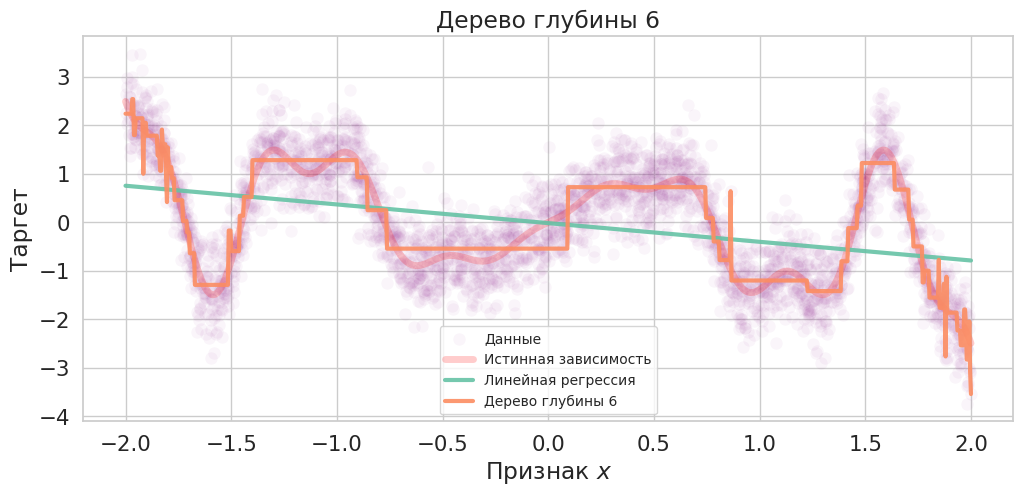

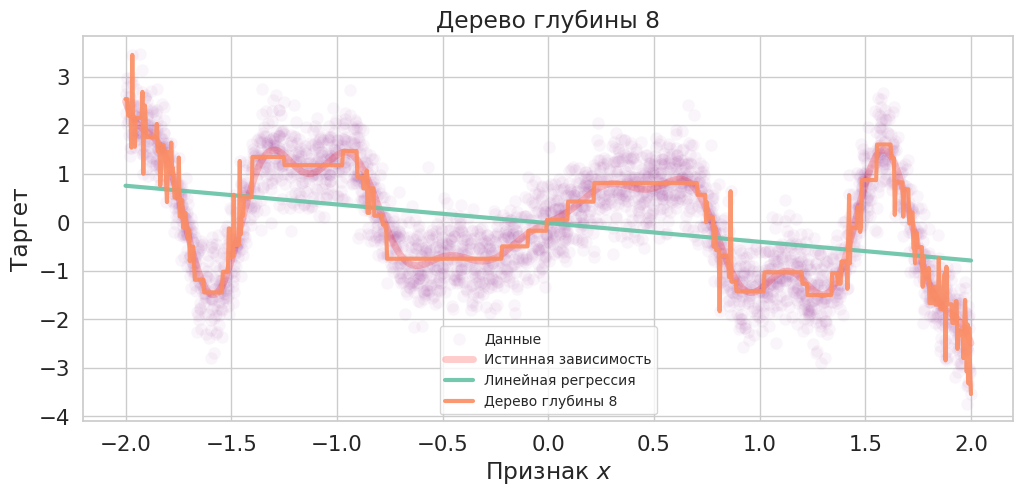

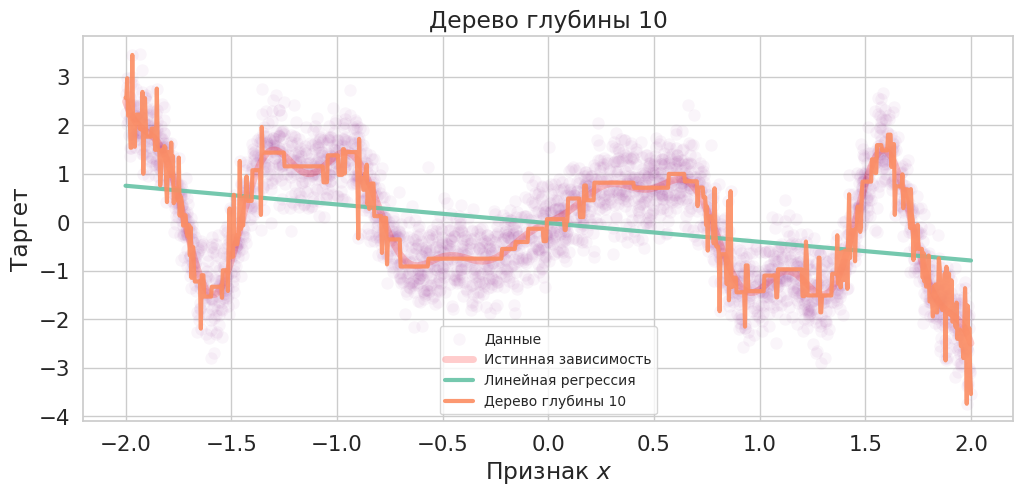

In [ ]:
linear_regression = LinearRegression()
linear_regression.fit(x_train_synthetic, y_train_synthetic)
model_preds = {"Линейная регрессия": linear_regression.predict(x_grid.reshape(-1, 1))}

for max_depth in [4, 6, 8, 10]:
    tree = DecisionTreeRegressor(max_depth=max_depth, random_state=RANDOM_STATE)
    tree.fit(x_train_synthetic, y_train_synthetic)

    tree_name = f'Дерево глубины {max_depth}'
    model_preds[tree_name] = tree.predict(x_grid.reshape(-1, 1))
    plot_regression_results(x_train_synthetic, y_train_synthetic, x_grid, y_grid_values,
                            model_preds=model_preds, title=f'Дерево глубины {max_depth}')
    del model_preds[tree_name]


Посмотрим на метрики.

In [ ]:
visualize_metric_df(synthetic_metrics_df)

,RMSE,MAE,MAPE,r2-score
Линейная регрессия,0.9702,0.8596,1.7089,0.1757
Дерево глубины 4,0.4857,0.3863,1.1074,0.7934
Дерево глубины 6,0.2486,0.1875,1.1541,0.9459
Дерево глубины 8,0.2256,0.1408,0.4652,0.9554
Дерево глубины 10,0.2744,0.1678,0.6355,0.9341


Итак, как и ранее наблюдаем следующие закономерности:
- **Линейная регрессия** работает очень плохо, так как истинная зависимость далека от линейной.
- **Неглубокое решающее дерево** (глубины 4-6) не смогло уловить большинство зависимостей.
- **Глубокое решающее дерево** (глубины 8-10) уловило все зависимости, но еще и сильно переобучилось на шум, что хорошо видно в областях графика с резкими изменениями значений функции.

## 2. Случайный лес

*Напоминание*: **случайный лес** подробно разбирался на теоретической ***лекции***, здесь приведено краткое повторение для понимания практики.

Чтобы снизить риск переобучения, вместо одного решающего дерева используют ансамбль — **случайный лес**. Он строит множество глубоких деревьев, каждое из которых обучается на случайной подвыборке объектов (с возвращением) и случайном подмножестве признаков. Затем их предсказания усредняются. В отличие от одного дерева, где переобучение возникает из-за малого числа объектов в листьях, в случайном лесе результат формируется усреднением по большому числу деревьев, а значит и большому числу объектов тренировочной выборки. Однако этот подход работает только тогда, когда деревья слабо коррелируют друг с другом — иначе усреднение по одинаковым элементам даёт мало выигрыша. Именно за счёт независимости деревьев **случайный лес** обеспечивает более высокую обобщающую способность: он сглаживает индивидуальные ошибки и делает предсказания устойчивыми, сохраняя при этом способность модели улавливать сложные зависимости.

#### Основные параметры

**Реализации: `RandomForestClassifier`, `RandomForestRegressor`**

Набор гиперпараметров случайного леса очень похож на набор гиперпараметров решающего дерева. Перечислим новые параметры:

* `n_estimators` — количество решающих деревьев, используемых для получения предсказаний. Это **основной гиперпараметр** случайного леса.

* `max_samples` — размер случайной подвыборки обучающей выборки (с возвращениями), используемой при построении каждого дерева.

* `max_features` — число признаков, используемых при построении каждого дерева. По умолчанию, корень от общего числа признаков для классификации и множество всех признаков для регрессии.

О других гиперпараметрах случайного леса можно почитать в документации <a href="https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html">классификатора</a> и <a href="https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html">регрессора</a>.

### 2.1 Синтетические данные

Попробуем обучить 100 деревьев и визуализируем полученные предсказания.

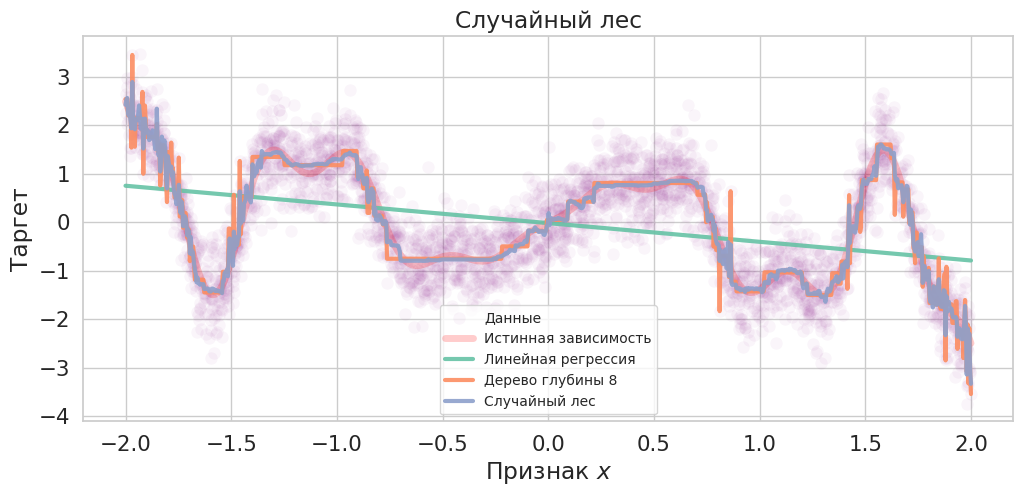

In [ ]:
# Сравним с деревом глубины 8
tree = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
tree.fit(x_train_synthetic, y_train_synthetic)
model_preds['Дерево глубины 8'] = tree.predict(x_grid.reshape(-1, 1))

# Создаем случайный лес из sklearn
random_forest = RandomForestRegressor(
    n_estimators=100,           # Количество деревьев в лесу
    max_depth=8,                # Максимальная глубина каждого дерева
    random_state=RANDOM_STATE,  # Фиксируем random_state
)
random_forest.fit(x_train_synthetic, y_train_synthetic)
model_preds['Случайный лес'] = random_forest.predict(x_grid.reshape(-1, 1))

# Строим график
plot_regression_results(x_train_synthetic, y_train_synthetic, x_grid, y_grid_values,
                        model_preds=model_preds, title=f'Случайный лес')


Посмотрим на метрики.

In [ ]:
visualize_metric_df(synthetic_metrics_df)

,RMSE,MAE,MAPE,r2-score
Линейная регрессия,0.9702,0.8596,1.7089,0.1757
Дерево глубины 4,0.4857,0.3863,1.1074,0.7934
Дерево глубины 6,0.2486,0.1875,1.1541,0.9459
Дерево глубины 8,0.2256,0.1408,0.4652,0.9554
Дерево глубины 10,0.2744,0.1678,0.6355,0.9341
Случайный лес,0.1491,0.1024,0.4132,0.9805


Метрики стали сильно лучше по сравнению с переобученным деревом, особенно RMSE!

Видим, что случайный лес, в самом деле, переобучился не так сильно, как решающее дерево: шум в обучающей выборке влияет на его предсказания сильно меньше, чем на предсказания одного дерева. Кроме того, предсказания, в целом, довольно сглажены и местами очень близки к истинной зависимости (например, в окрестности -0.75 или -0.2 по оси X).

**Вывод:**

1. **Линейная регрессия** не способна уловить сложную нелинейную структуру данных и выдает прямую линию, что далеко от истинной зависимости.

2. **Решающее дерево** либо недообучается, либо сильно переобучается, повторяя шум в данных.

3. **Случайный лес** тоже переобучается, но не так сильно как решающее дерево. Это происходит потому что каждое из деревьев в случайном лесу обучается на случайной подвыборке данных, а это снижает риск полного переобучения на одну точку.

Таким образом, случайный лес лучше справляется с задачей по сравнению с решающим деревом за счет меньшей склонности к переобучению.


### 2.2 Решающая поверхность для случайного леса

Давайте теперь, как и на предудущем семинаре, посмотрим на решающую поверхность в пространстве синтетических двумерных данных.

Сгенирируем данные со сложной спиралевидной зависимостью.

In [ ]:
n_samples = 2000
np.random.seed(RANDOM_STATE)

# Генерируем двумерные признаки из нормального распределения
X = np.random.randn(n_samples, 2)

# Переводим в полярные координаты для удобства определения спирали
r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)       # радиус
theta = np.arctan2(X[:, 1], X[:, 0])       # угол [-pi, pi]

# Делаем таргет со спиралевидной зависимостью
y = np.sin(2 * theta + 5 * r) + 1.2 * np.random.randn(n_samples)

Визуализируем. Отклик показан цветом точки.

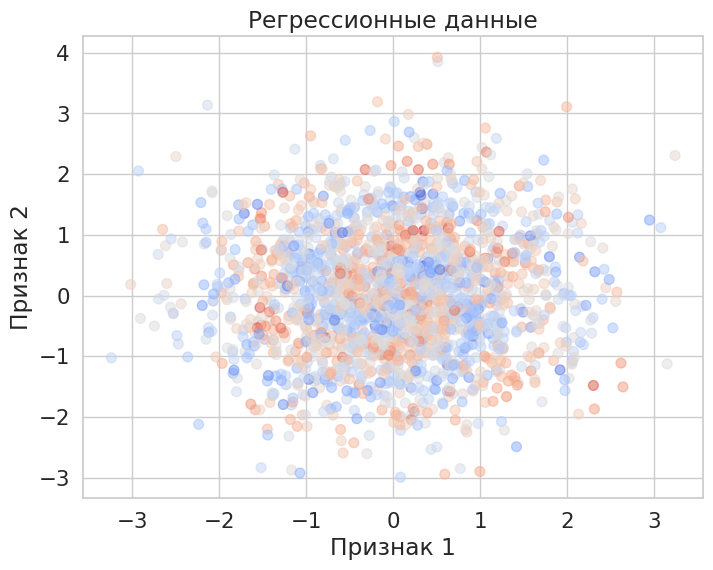

In [ ]:
grid_x1 = X[:, 0]
grid_x2 = X[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(grid_x1, grid_x2, c=y, s=50, alpha=0.5, cmap='coolwarm')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Регрессионные данные')
plt.show()

Напишем код для отрисовки

In [ ]:
def get_meshgrid(data: np.ndarray, step: float, border: float = 0.5):
    '''
    Функция для получения сетки точек (x1, x2)
    для дальнейшего отображения их на графиках

    Параметры:
    data (np.ndarray): входной датасет, набор точек (x1_i, x2_i)
    step (float): мелкость сетки
    border (float): отступ от минимальных и максимальных значений x1, x2 в data
    в сетке
    '''

    x1_min, x1_max = data[:, 0].min() - border, data[:, 0].max() + border
    x2_min, x2_max = data[:, 1].min() - border, data[:, 1].max() + border
    return np.meshgrid(np.arange(x1_min, x1_max, step),
                       np.arange(x2_min, x2_max, step))


def plot_decision_surface(
    model: BaseEstimator,
    X_train: np.ndarray,
    y_train: Optional[np.ndarray] = None,
    border: float = 1,
    step: float = 0.05,
    cmap: str = 'spring',
    figsize: Optional[Tuple[int, int]] = None,
    scatter_kwargs: Dict[str, Any] = None,
):
    '''
    Раскрашивает пространство в соответствии с предсказаниями
    случайного леса/решающего дерева

    Параметры:
    model (BaseEstimator): визуализируемая модель
    X_train (np.ndarray): данные обучающей выборки
    y_train (np.ndarray): метки обучающей выборки (если None, то не отрисовываются)
    border (float): размер границы между областями пространства, полученными моделью
    step (float): точность сетки пространства
    cmap (str): цветовая схема
    figsize (tuple): размер создаваемой фигуры (если None, то новая фигура не создается)
    scatter_kwargs (dict): словарь с аргументами для plt.scatter
    '''

    scatter_kwargs = scatter_kwargs or {}

    # Создание сетки
    grid = get_meshgrid(X_train, step, border)
    # Выворачивание сетки для применения модели
    grid_ravel = np.c_[grid[0].ravel(), grid[1].ravel()]

    # Предсказание значений для сетки
    grid_predicted_ravel = model.predict(grid_ravel)
    grid_predicted = grid_predicted_ravel.reshape(grid[0].shape)  # Подгоняем размер

    # Построение фигуры
    if figsize is not None:
        plt.figure(figsize=figsize)

    plt.pcolormesh(grid[0], grid[1], grid_predicted, cmap=cmap, shading='auto')
    if y_train is not None:
        plt.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap,
            edgecolors='black', **scatter_kwargs,
        )

    plt.xlim((min(grid_ravel[:, 0]), max(grid_ravel[:, 0])))
    plt.ylim((min(grid_ravel[:, 1]), max(grid_ravel[:, 1])))

    if figsize is not None:
        plt.show()


Разобъём данные на обучение и тест.

In [ ]:
X_train_synthetic, X_test_synthetic, y_train_synthetic, y_test_synthetic = \
    train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

Обучим несколько случайных лесов на 35 деревьях для удобства визуализации. Переберем несколько разных `max_depth` и выберем лучший.

*Комментарий.* Так как здесь используется небольшое количество деревьев и двумерные данные, имеет смысл ограничить высоту для уменьшения переобучения. В реальных задачах при использовании большого количества деревьев высоту обычно не ограничивают.

In [ ]:
synthetic_2d_metrics_df = pd.DataFrame()

n_estimators = 35

for max_depth in [6, 8, 10, 12, 15]:
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=RANDOM_STATE)
    model.fit(X_train_synthetic, y_train_synthetic)

    name = f'Случайный лес, max_depth = {max_depth}'
    evaluate_regression(name, y_test_synthetic, model.predict(X_test_synthetic), synthetic_2d_metrics_df, prefix='test_')
    evaluate_regression(name, y_train_synthetic, model.predict(X_train_synthetic), synthetic_2d_metrics_df, prefix='train_')

visualize_metric_df(synthetic_2d_metrics_df)

,test_RMSE,test_MAE,test_MAPE,test_r2-score,train_RMSE,train_MAE,train_MAPE,train_r2-score
"Случайный лес, max_depth = 6",1.3063,1.0651,6.0095,0.0583,1.2413,0.9818,22.9657,0.2096
"Случайный лес, max_depth = 8",1.2958,1.0563,6.8422,0.0733,1.1282,0.8940,28.5731,0.3471
"Случайный лес, max_depth = 10",1.2879,1.0450,6.6664,0.0847,0.9940,0.7870,28.5255,0.4931
"Случайный лес, max_depth = 12",1.2929,1.0441,7.0379,0.0775,0.8579,0.6805,23.4616,0.6225
"Случайный лес, max_depth = 15",1.3139,1.0524,6.9251,0.0474,0.6810,0.5408,19.5077,0.7621


Стоит отметить, что на MAPE в данной задаче смотреть некорректно, так как область значений таргета пересекается с нулем. Выберем глубину 10, у нее лучшие значения RMSE и R2-score.

In [ ]:
model = RandomForestRegressor(n_estimators=n_estimators, max_depth=10, random_state=RANDOM_STATE)
model.fit(X_train_synthetic, y_train_synthetic)

RandomForestRegressor(max_depth=10, n_estimators=35, random_state=42)

Визуализация предсказания по каждому из деревьев по отдельности.

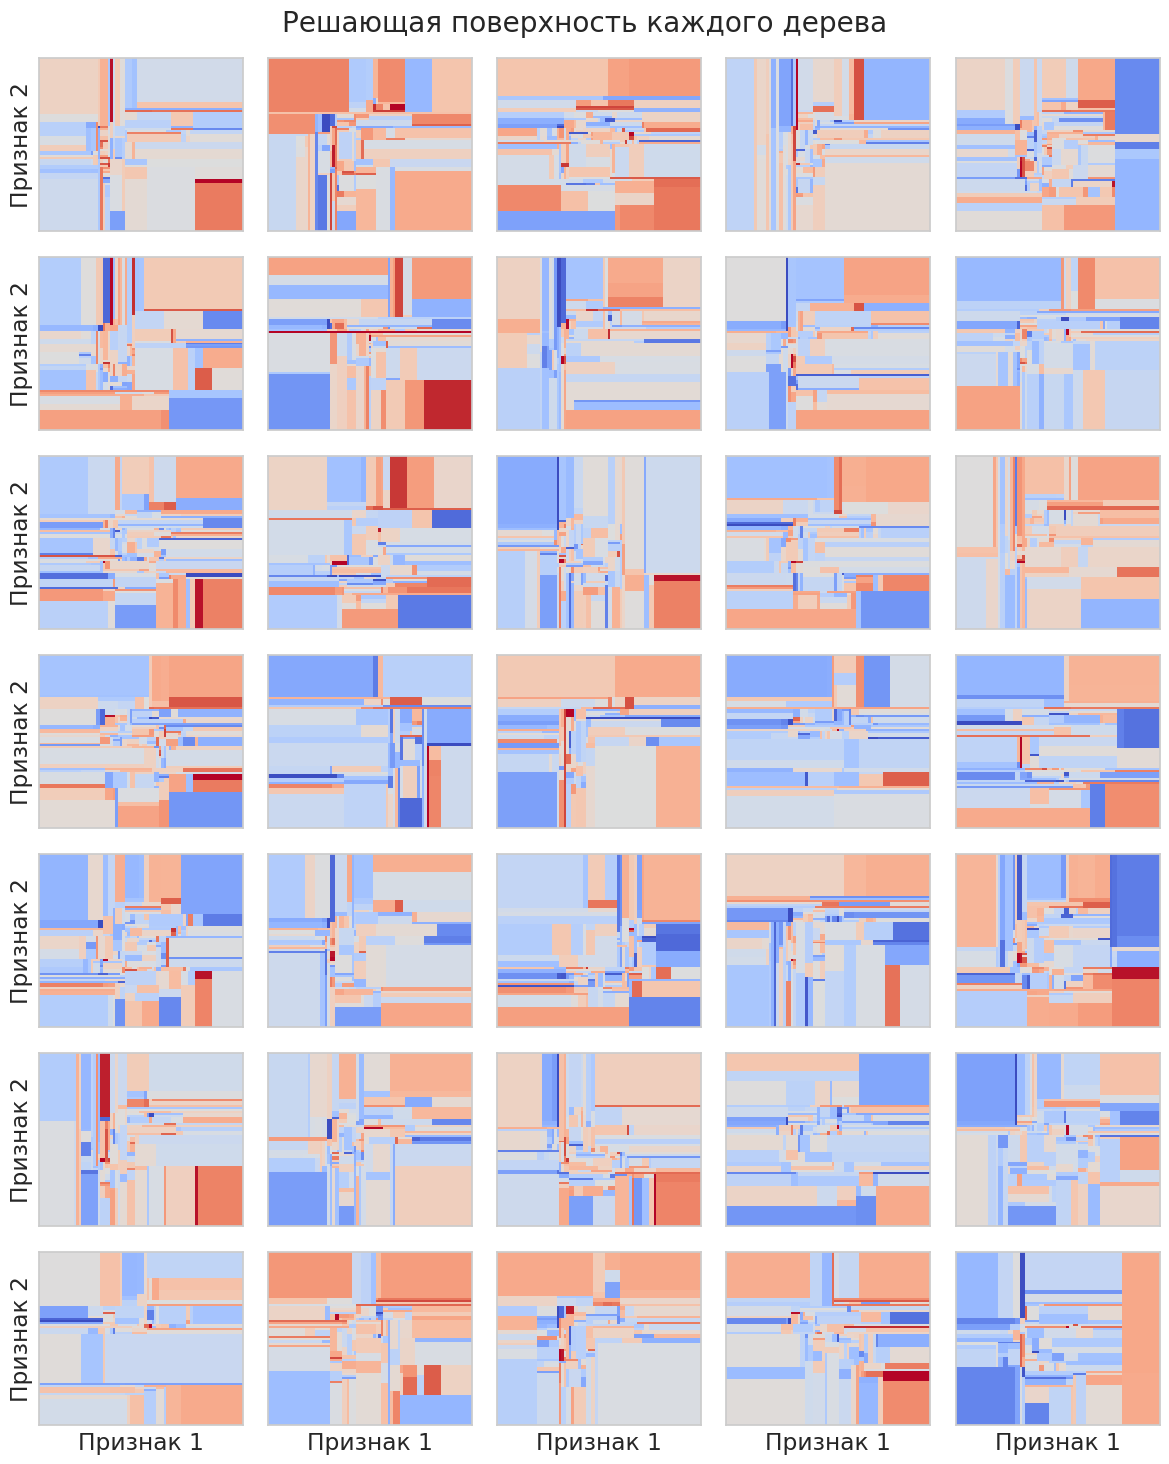

In [ ]:
plt.figure(figsize=(12, 15))
plt.suptitle('Решающая поверхность каждого дерева')
for i in range(n_estimators):
    plt.subplot(int(np.floor(n_estimators / 5)), 5, i+1)

    plot_decision_surface(
        model=model.estimators_[i],
        X_train=X_train_synthetic,
        step=0.1,
        cmap='coolwarm',
    )

    plt.title('')
    plt.xticks([])
    plt.yticks([])

    if i % 5 == 0:
        plt.ylabel('Признак 2')
    if i >= n_estimators - 5:
        plt.xlabel('Признак 1')

plt.tight_layout()


Все деревья такие разные, переобученные и вообще не похожие на спираль...


&#x2753; **Вопрос** &#x2753;

> Почему деревья такие разные?

<details>
 <summary> Кликни для показа ответа </summary>

 > Каждое дерево обучается на своей случайной подвыборке элементов обучающих данных, отсюда и берется случайность.

 > Обратите внимание, что в данной задаче случайного выбора признаков не происходит, так как по умолчанию в sklearn для регрессии в каждом дереве берутся все признаки.

</details><br/>

Теперь посмотрим на предсказание случайного леса, то есть усреднение всех деревьев.

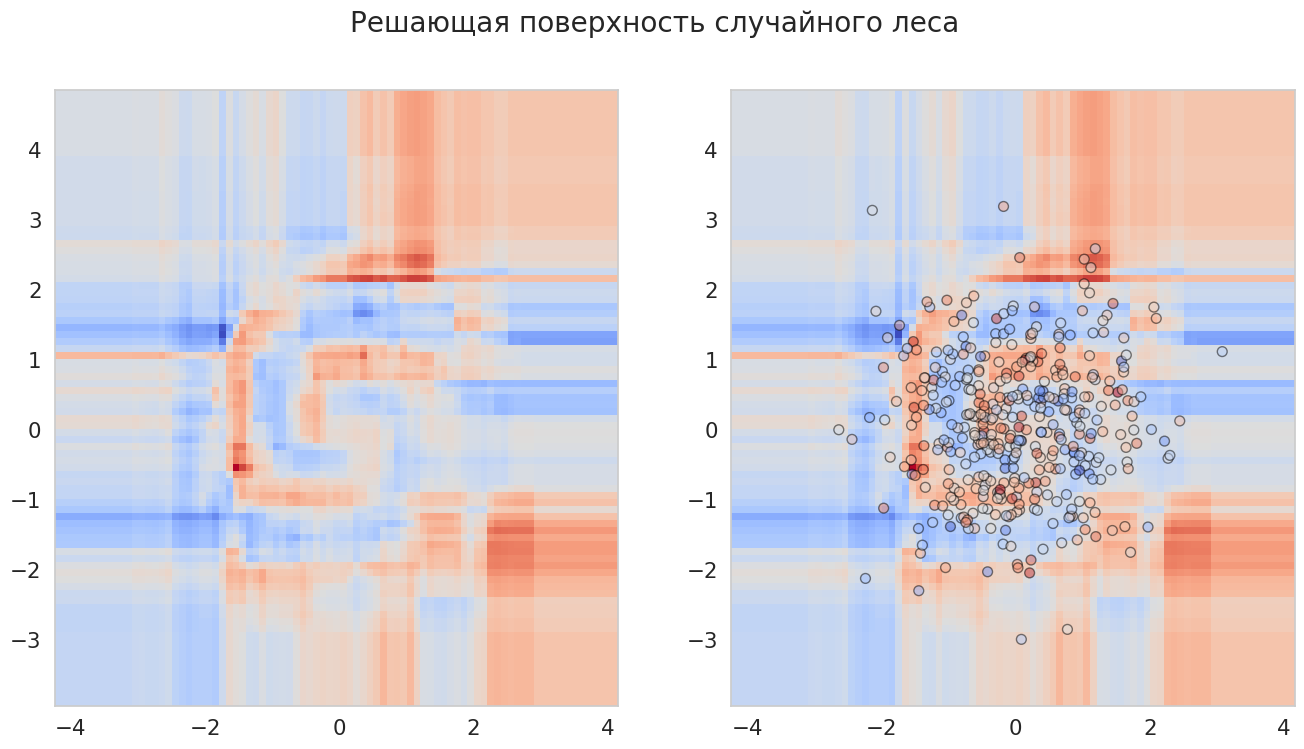

In [ ]:
plt.figure(figsize=(16, 8))
plt.suptitle('Решающая поверхность случайного леса')

for i in range(2):
    plt.subplot(1, 2, i + 1)
    plot_decision_surface(
        model=model,
        X_train=X_train_synthetic,
        step=0.1,
        cmap='coolwarm',
    )
    if i == 1:
        plt.scatter(X_test_synthetic[:, 0], X_test_synthetic[:, 1], c=y_test_synthetic, s=50,
                    alpha=0.5, edgecolors='black', cmap='coolwarm')
plt.show()

**Вывод**

Отдельные деревья в лесу выглядят сильно переобученными: они создают сложные, неровные кусочно-постоянные разделения пространства, отражающие детали и шум обучающих данных. Каждое дерево обучается на своей подвыборке данных, из-за чего их решения различаются и еще меньше похожи на спираль. Однако при усреднении всех деревьев в случайном лесу шум отдельных моделей сглаживается, и итоговая поверхность становится более гладкой, интуитивно понятной и обобщенной. Это уменьшает дисперсию модели и делает её менее склонной к переобучению.

### 2.3 Реальные данные

Вернемся к датасету California Housing Prices и попробуем применить на нем случайный лес.

In [ ]:
random_forest = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=RANDOM_STATE)
random_forest.fit(X_train, y_train)

evaluate_regression('Случайный лес', y_test, random_forest.predict(X_test), houses_metrics_df, prefix='test_')
evaluate_regression('Случайный лес', y_train, random_forest.predict(X_train), houses_metrics_df, prefix='train_')
visualize_metric_df(houses_metrics_df)

,test_RMSE,test_MAE,test_MAPE,test_r2-score,train_RMSE,train_MAE,train_MAPE,train_r2-score
Решающее дерево глубиной 10,62780.4881,41291.6966,0.2221,0.7118,47248.4848,31811.5482,0.1781,0.8313
Решающее дерево глубиной 12,63466.3449,40325.4477,0.2140,0.7055,37572.0820,24002.7801,0.1370,0.8934
Решающее дерево глубиной 15,66404.7386,41485.1096,0.2225,0.6775,23435.4456,12899.4749,0.0762,0.9585
Линейная регрессия,69699.1370,50950.1022,0.2964,0.6448,69190.6092,50342.1788,0.2977,0.6383
Случайный лес,51477.2901,34240.0627,0.1883,0.8062,34582.7231,23979.1448,0.1381,0.9096


Случайный лес дал значительный прирост качества и в реальной задаче оценки стоимости домов на тестовой выборке!

На train части ожидаемо лучше всего себя показало самое глубокое дерево, так как оно сильно переобучилось на эту выборку.

## 3. Решение задачи классификации с помощью случайного леса

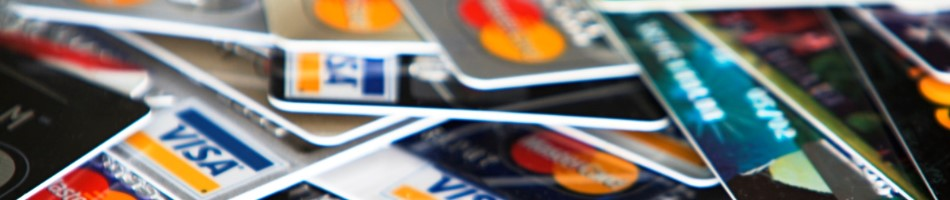

Теперь проделаем похожие эксперименты для задачи классификации. Возьмём датасет [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) для классификации мошеннических транзакций.

Признаки, содержащиеся в датасете:
* `Time` &mdash; время, прошедшее между данной транзакцией и первой транзкцией из датасета;
* `V1-V28` &mdash; анонимизированные признаки для сохранения конфиденциальности;
* `Amount` &mdash; сумма транзакции;
* `Class` &mdash; целевой класс, является ли транзакция мошеннической.

Скачаем датасет из kaggle.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
data = pd.read_csv(path + "/creditcard.csv")
data.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 3.1 Зависимость точности классификации от значений гиперпараметров

Разобьём данные на обучающую и тестовую выборки.

In [ ]:
X = data.iloc[:, 1:30]
y = data['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

Посмотрим на распределение целевого признака.

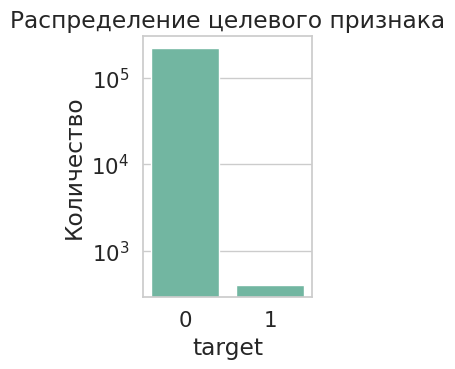

In [ ]:
# Считаем количество примеров каждого класса
counts = y_train.value_counts().sort_index()

plt.figure(figsize=(3, 4))
sns.barplot(x=counts.index.astype(str), y=counts.values)
plt.yscale('log')
plt.title('Распределение целевого признака')
plt.xlabel('target')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

Как видно только нулевого класса сильно больше. Точные значения:

In [ ]:
counts

,count
Class,
0,227451
1,394


Видим сильный дизбаланс классов.

&#x2753; **Вопрос** &#x2753;

> На какую метрику классификации лучше всего смотреть в данной задаче? Почему?

<details>
 <summary> Кликни для показа ответа </summary>

 > С таким дизбалансом классов обычный accuracy точно будет бесполезен. В данной задаче намного страшнее не задетектить мошенническую операцию, чем ошибочно посчитать обычную транзакцию немошеннической. То есть нам важна **полнота** (**recall**) &mdash; доля правильно предсказанных среди всех объектов положительного класса.
 >
 > Но совсем игнорировать precision тоже плохо, поэтому будем рассматривать $f_\beta = \dfrac{ \left(1 + \beta^2\right) \cdot Precision \cdot Recall}{\beta^2 Precision + Recall}$ для $\beta = 2$, тем самым отдавая приоритет recall.
</details><br/>


Для начала, попробуем оценить оптимальное количество решающих деревьев в лесу, взяв значения всех остальных параметров по умолчанию. Построим график зависимости $f_2$ от `n_estimators` на обучающей и на тестовой выборках. Дефолтное значение в sklearn `n_estimators=100`, далее рассмотрим более широкий набор значений — от 1 до 200.

Заметим, что не обязательно учить для каждого параметра `n_estimators` заново весь лес. Можно вначале обучить одну модель для с максимальным количеством деревьев (200), а затем для получения предсказания для произвольного `n_estimators` просто усреднять предсказания первых `n_estimators` деревьев. Посколько деревья строятся независимо, такой подход будет эквивалентен обучению леса с нуля для каждого значения параметра.

In [ ]:
def cum_metric(
    model: RandomForestRegressor,
    metric: Callable[[np.ndarray, np.ndarray], float],
    x_test: np.ndarray,
    y_test: np.ndarray,
    shuffle: bool = False,
    binary_ths: float = 0.5,
):
    '''
    Считает значения метрики metric в зависимости от количества деревьев
    в обученной модели model метом композиции деревьев.

    Параметры:
    model (RandomForestRegressor): модель RandomForest
    metric (Callable[[np.ndarray, np.ndarray], float]): метрика
    x_test (np.ndarray): тестовая выборка
    y_test (np.ndarray): ответы на тестовой выборке
    shuffle (bool): надо ли перемешивать деревья
    binary_ths (float): порог вероятности для истинного класса
                       в случае задачи классификации

    Возвращает: кумулятивные значения метрики
    '''

    # Поведение для классификатора и регрессии будет немного отличаться
    is_classifier = isinstance(model, RandomForestClassifier)

    # Считаем предсказания по каждому дереву отдельно
    predictions_by_estimators = [
        est.predict_proba(x_test)[:, 1] if is_classifier else est.predict(x_test)
        for est in model.estimators_
    ]

    if shuffle:
        random.shuffle(predictions_by_estimators)

    numerator = np.cumsum(predictions_by_estimators, axis=0)
    n = len(predictions_by_estimators)
    denominator = (np.arange(n) + 1)[:, np.newaxis]
    cumpred = numerator / denominator

    if is_classifier:
        cumpred = cumpred > binary_ths

    cumacc = [metric(y_test, pred) for pred in cumpred]
    return np.array(cumacc)

def plot_some_lines(
    lines: Dict[str, np.ndarray],
    xlabel: str,
    estrimator_range: Optional[np.ndarray] = None,
    title: Optional[str] = None,
    metric_name: str = 'MSE',
):
    '''
    Отрисовывает линии из словаря lines

    Параметры:
    lines (Dict[str, np.ndarray]): словарь линий, ключ - label, значение - линия
    xlabel (str): название оси X
    estrimator_range (np.ndarray): значения на оси X
    metric_name (Optional[str]): имя метрики
    title (str): заголовок графика
    '''

    with sns.axes_style("darkgrid"):
        plt.figure(figsize=(12, 6))
        plt.title(title, fontsize=20)

        for name, line in lines.items():
            if estrimator_range is not None:
                plt.plot(estrimator_range, line, label=name, lw=3)
            else:
                plt.plot(line, label=name, lw=3)
        plt.grid(ls=':')
        plt.xlabel(xlabel)
        plt.ylabel(f'Метрика {metric_name}')
        plt.legend(fontsize=14)
        plt.show()


Обучим лес на 200 деревьев.

In [ ]:
%%time
random_forest = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
random_forest.fit(X_train, y_train)

CPU times: user 12min 48s, sys: 1.33 s, total: 12min 49s
Wall time: 12min 57s


RandomForestClassifier(n_estimators=200, random_state=42)

Посмотрим на кумулятивные метрики.

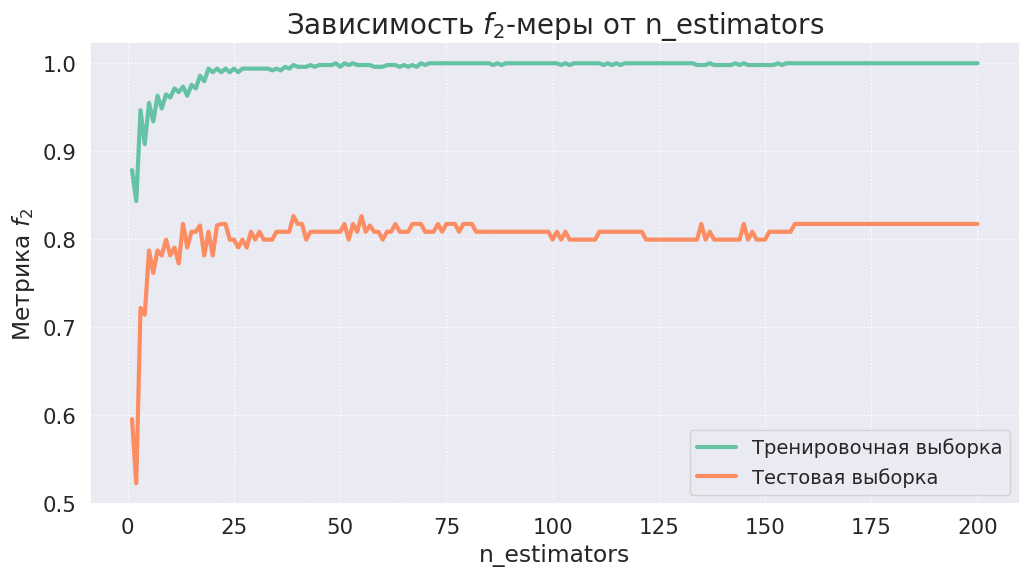

In [ ]:
beta = 2

fbeta_score = lambda y_true, y_pred: metrics.fbeta_score(y_true, y_pred, beta=beta)

cum_fbeta_train = cum_metric(random_forest, fbeta_score, X_train.to_numpy(), y_train)
cum_fbeta_test = cum_metric(random_forest, fbeta_score, X_test.to_numpy(), y_test)
estrimator_range = np.arange(random_forest.n_estimators) + 1

plot_some_lines(
    lines={
        'Тренировочная выборка': cum_fbeta_train,
        'Тестовая выборка': cum_fbeta_test,
    },
    xlabel='n_estimators',
    estrimator_range=estrimator_range,
    title=f'Зависимость $f_{beta}$-меры от n_estimators',
    metric_name=f'$f_{beta}$',
)

Как можно заметить, при `n_estimators` > 80 заметных улучшений по $f_2$ как на обучающей, так и на тестовой выборке не происходит. Но она и не ухудшается! То есть дальнейшее увеличение количества деревьев никак не повлияет на качество, лишь увеличит потребление вычислительных ресурсов.

Теперь зафиксируем `n_estimators` равным 80 и будем использовать это значение во всех последующих экспериментах с данным датасетом. Построим график зависимости $f_2$ от `min_samples_leaf` на обучающей и на тестовой выборках.

In [ ]:
def get_train_and_test_fbeta(
    param_name: str,
    grid: Sequence[Any],
    other_params_dict: Dict[str, Any] = {},
    beta: float = 1.0
):
    '''
    Функция для оценки точности классификации
    для заданных значений параметра param_name

    Параметры:
    param_name (str): название параметра, который собираемся варьировать
    grid (Sequence[Any]): сетка значений параметра
    other_params_dict (Dict[str, Any]): словарь со значениями остальных параметров
    beta (float): параметр beta в f-мере
    '''

    train_fbeta, test_fbeta = [], []
    params_dict = copy.copy(other_params_dict)

    for param_value in tqdm(grid):
        params_dict.update({param_name: param_value})
        estimator = RandomForestClassifier(**params_dict, random_state=RANDOM_STATE, n_jobs=-1)
        estimator.fit(X_train, y_train)

        train_fbeta.append(metrics.fbeta_score(y_train, estimator.predict(X_train), beta=beta))
        test_fbeta.append(metrics.fbeta_score(y_test, estimator.predict(X_test), beta=beta))

    return train_fbeta, test_fbeta

def plot_dependence(
    param_name: str,
    grid: Sequence[Any] = range(2, 20),
    other_params_dict: Dict[str, Any] = {},
    beta: float = 1.0,
):
    '''
    Функция для отображения графика зависимости f_beta
    от значения параметра c названием param_name

    Параметры:
    param_name (str): название параметра, который собираемся варьировать
    grid (Sequence[Any]): сетка значений параметра
    other_params_dict (Dict[str, Any]): словарь со значениями остальных параметров
    beta (float): параметр beta в f-мере
    '''

    train_fbeta, test_fbeta = get_train_and_test_fbeta(
        param_name, grid, other_params_dict, beta=beta
    )

    plot_some_lines(
        lines={
            'Тренировочная выборка': train_fbeta,
            'Тестовая выборка': test_fbeta,
        },
        xlabel=param_name,
        estrimator_range=grid,
        title=f'Зависимость $f_{beta}$-меры от {param_name}',
        metric_name=f'$f_{beta}$',
    )


  0%|          | 0/10 [00:00<?, ?it/s]

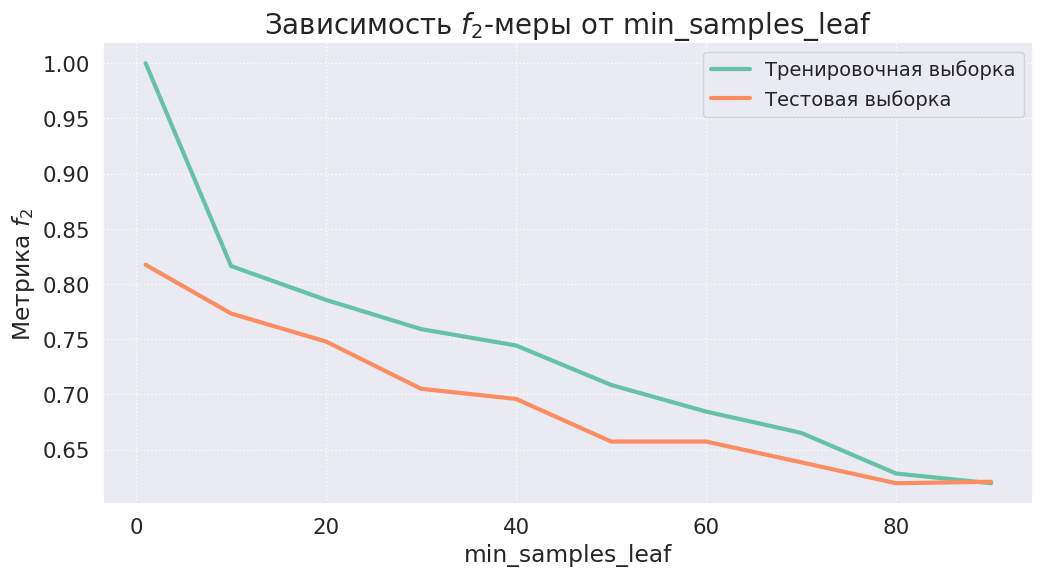

CPU times: user 1h 2min 30s, sys: 7.27 s, total: 1h 2min 37s
Wall time: 36min 3s


In [ ]:
%%time
plot_dependence(
    'min_samples_leaf', [1] + list(range(10, 100, 10)), {'n_estimators': 80},
    beta=2,
)

**Вывод.**

В целом наблюдается следующая закономерность: с увеличением значения `min_samples_leaf` падает качество и на обучающей, и на тестовой выборке. Напомним, что при использовании одного решающего дерева закономерность была иной: до некоторого значения `min_samples_leaf` качество на тестовой выборке повышалось.

  0%|          | 0/10 [00:00<?, ?it/s]

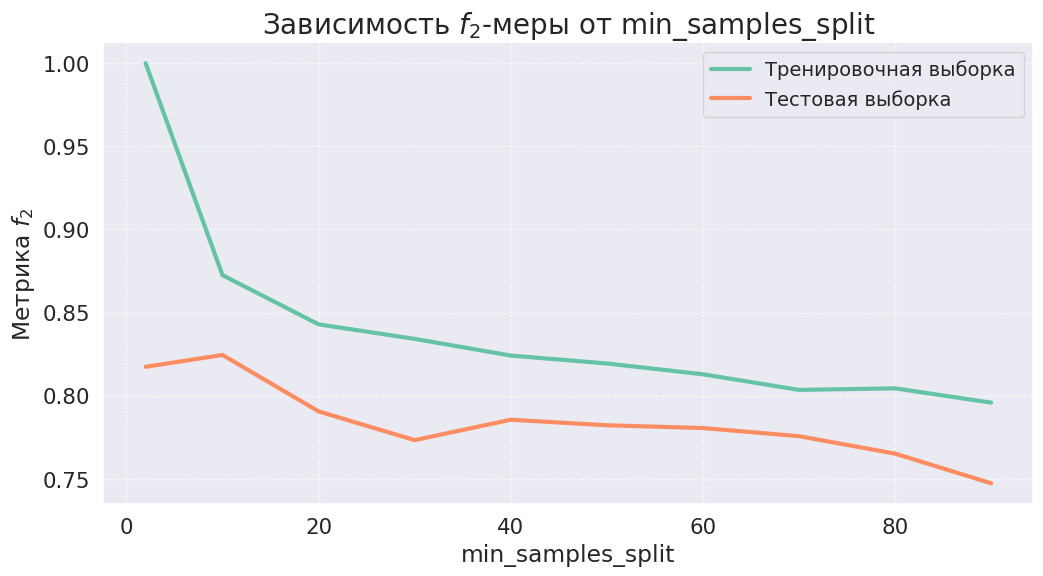

CPU times: user 1h 8min 5s, sys: 7.07 s, total: 1h 8min 13s
Wall time: 38min 58s


In [ ]:
%%time
plot_dependence(
    'min_samples_split', [2] + list(range(10, 100, 10)), {'n_estimators': 80},
    beta=2,
)

**Вывод.**

При повышении значения `min_samples_split` происходит то же, что и при повышении `min_samples_leaf`.

  0%|          | 0/10 [00:00<?, ?it/s]

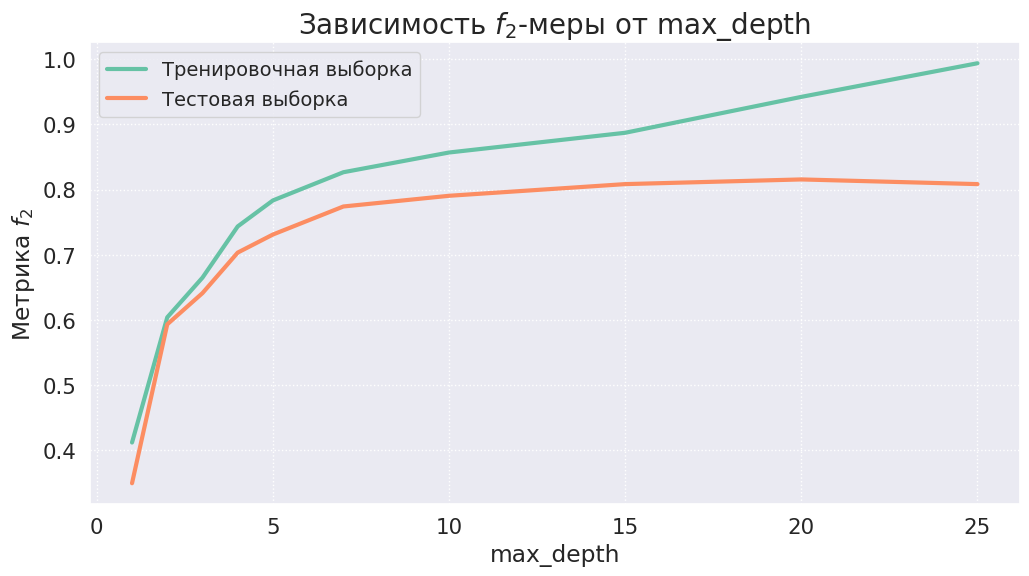

CPU times: user 31min 58s, sys: 3.51 s, total: 32min 2s
Wall time: 18min 17s


In [ ]:
%%time
plot_dependence(
    'max_depth', [1, 2, 3, 4, 5, 7, 10, 15, 20, 25], {'n_estimators': 80},
    beta=2,
)

**Вывод.**

При повышении значения `max_depth` качество на тесте растет и стабилизируется. Вспомним, что для решающего дерева поведение было иным: для большой глубины происходило сильное переобучение и качество ухудшалось, оптимальными были значения порядка 5.

Итак, мы поняли, что с увеличением количества деревьев и максимальной глубины качество растет, с увеличением `min_samples_leaf` и `min_samples_split` — падает. Это согласуется с теорией:
- Увеличение количества деревьев снижает дисперсию модели и ведет к более устойчивым результатам (хотя после некоторого значения качество перестаёт расти, а время обучения увеличивается)
- Увеличение глубины отдельных деревьев позволяет лучше улавливать сложные зависимости в данных без сильного риска переобучения, так как усреднение в лесу сглаживает переобучение каждого дерева
- Уменьшение `min_samples_leaf` и `min_samples_split` также делает деревья более гибкими и позволяет модели точнее подстраиваться под данные, чрезмерное увеличение этих параметров приводит к потере качества из-за слишком грубого разбиения.

Таким образом, в случайном лесу лучше использовать много переобученных деревьев.

Обучим финальный случайный лес с соответствующими параметрами, сравним его качество с деревом и логистической регрессией.

In [ ]:
%%time
models = {
    'Логистическая регрессия': LogisticRegression(max_iter=1000),
    'Решающее дерево глубиной 10': DecisionTreeClassifier(max_depth=10),
    'Решающее дерево глубиной 12': DecisionTreeClassifier(max_depth=12),
    'Решающее дерево глубиной 15': DecisionTreeClassifier(max_depth=15),
    'Случайный лес': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=80, max_depth=None, min_samples_leaf=1),
}

for model in models.values():
    model.fit(X_train, y_train)

CPU times: user 7min 18s, sys: 219 ms, total: 7min 19s
Wall time: 7min 2s


In [ ]:
classification_metrics = {
    f'f-{beta}': fbeta_score,
    'precision': metrics.precision_score,
    'recall': metrics.recall_score,
    'accuracy': metrics.accuracy_score
}

classification_metrics_df = pd.DataFrame()

for model_name, model in models.items():
    evaluate_regression(model_name, y_test, model.predict(X_test),
                        classification_metrics_df, prefix='test_',
                        metrics_dict=classification_metrics)
    evaluate_regression(model_name, y_train, model.predict(X_train),
                        classification_metrics_df, prefix='train_',
                        metrics_dict=classification_metrics)
visualize_metric_df(classification_metrics_df)

,test_f-2,test_precision,test_recall,test_accuracy,train_f-2,train_precision,train_recall,train_accuracy
Логистическая регрессия,0.6318,0.8657,0.5918,0.9991,0.6708,0.8893,0.6320,0.9992
Решающее дерево глубиной 10,0.7862,0.8824,0.7653,0.9994,0.8830,1.0000,0.8579,0.9998
Решающее дерево глубиной 12,0.7780,0.8333,0.7653,0.9993,0.9065,1.0000,0.8858,0.9998
Решающее дерево глубиной 15,0.7771,0.7835,0.7755,0.9992,0.9548,1.0000,0.9442,0.9999
Случайный лес,0.8174,0.9747,0.7857,0.9996,1.0000,1.0000,1.0000,1.0000


Видим, что и в задаче классификации случайный лес справился лучше других моделей.

## 4. Переобучение случайного леса

***Напоминание***

>**Переобучение** &mdash; явление, при котором построенная модель хорошо объясняет объекты из обучающей выборки, но относительно плохо работает на объектах, не участвовавших в обучении, например, на объектах из тестовой/валидационной выборок.
>
>Это связано с тем, что при обучении модели в обучающей выборке обнаруживаются некоторые случайные закономерности, которые отсутствуют в глобальном смысле.

### 4.1. Сильно шумные данные

Вернемся к синтетическим данным и подробнее изучим поведение случайного леса на зашумленном датасете.

Сгенерируем сильно зашумленную зависимость:
1. Выбираем $x$ случайно на отрезке $[-5, 5]$
2. Генерируем $y=x + \mathcal{N} (0, 10^2)$
3. Берем признаки:
    * $x$;
    * $x^2$.

Обучим на этих данных случайный лес на 200 деревьев и обычную линейную регрессию.

In [ ]:
np.random.seed(44)  # специально подобрано, чтобы показать "что бывает" :)

train_size = 100  # размер обучающей выборки
poly_degree = 2  # максимальная степень полинома
noise_scale = 10  # станд. отклонение шума
n_estimators = 200  # количество деревьев

# Генерируем выборку
x_train = sps.uniform(loc=-5, scale=10).rvs(size=(train_size, 1))
y_train = x_train.ravel() + sps.norm(scale=noise_scale).rvs(size=train_size)
features_train = x_train ** np.arange(1, poly_degree+1)

# Обучаем модели
rf = RandomForestRegressor(n_estimators=n_estimators).fit(
    features_train, y_train
)
lr = LinearRegression().fit(features_train, y_train)

Для обоих методов построим предсказания по сетке.

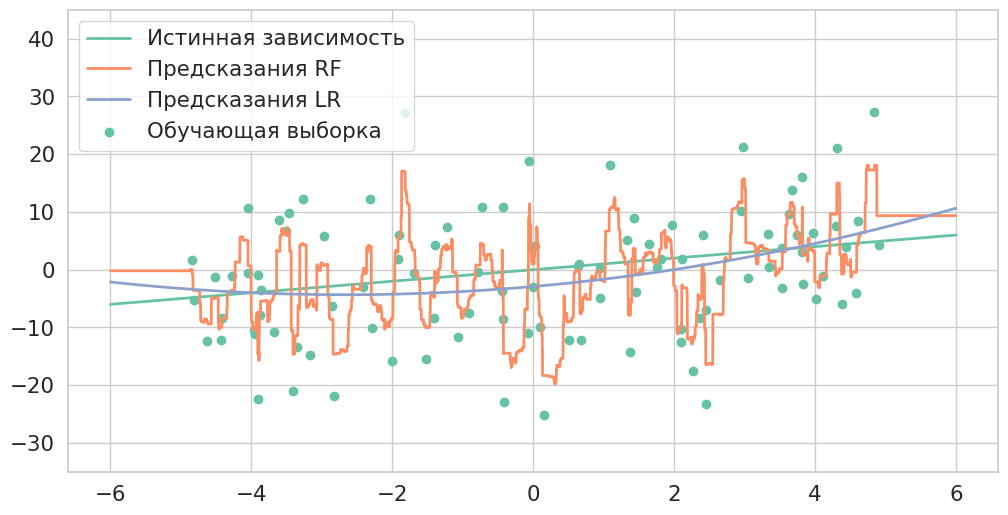

In [ ]:
grid = np.arange(-6, 6, 0.001)
features_test = grid[:, np.newaxis] ** np.arange(1, poly_degree+1)
preds_rf = rf.predict(features_test)
preds_lr = lr.predict(features_test)

plt.figure(figsize=(12, 6))
plt.plot(grid, grid, label='Истинная зависимость', lw=2)
plt.plot(grid, preds_rf, label='Предсказания RF', lw=2)
plt.plot(grid, preds_lr, label='Предсказания LR', lw=2)
plt.scatter(x_train, y_train, label='Обучающая выборка')
plt.legend(loc=2)
plt.ylim((-35, 45))
plt.show()

Как видим, предсказания случайного леса очень шумные, явно видно сильное переобучение.

Посчитаем метрики на обучающей и тестовой выборках для обеих моделей.

In [ ]:
# Зашумляем метки на тесте аналогичным образом
y_grid = grid + sps.norm(scale=noise_scale).rvs(size=len(grid))

noisy_models = {
    'Случайный лес': rf,
    'Линейная регрессия': lr,
}
noisy_metrics_df = pd.DataFrame()

for model_name, model in noisy_models.items():
    evaluate_regression(model_name, y_grid, model.predict(features_test),
                        noisy_metrics_df, prefix='test_')
    evaluate_regression(model_name, y_train, model.predict(features_train),
                        noisy_metrics_df, prefix='train_')
visualize_metric_df(noisy_metrics_df)

,test_RMSE,test_MAE,test_MAPE,test_r2-score,train_RMSE,train_MAE,train_MAPE,train_r2-score
Случайный лес,12.1786,9.7125,4.5860,-0.3278,4.6374,3.8606,0.8238,0.8214
Линейная регрессия,10.2370,8.1821,2.8682,0.0619,10.4139,8.3249,1.4037,0.0995


Как видим, ошибка на тесте для случайного леса существенно выше ошибки на трейне, это явно говорит о сильном переобучении.  В то же время ошибки для линейной регрессии слабо отличаются, т.е. возможно, что линейная регрессия не переобучается. Более того, ошибка на тесте для линейной регрессии существенно ниже ошибки для случайного леса.

#### 4.1.1 Зависимость от количества деревьев для одной модели

Построим график зависимости MSE от количества деревьев в случайном лесе для обучающей и тествой выборок.

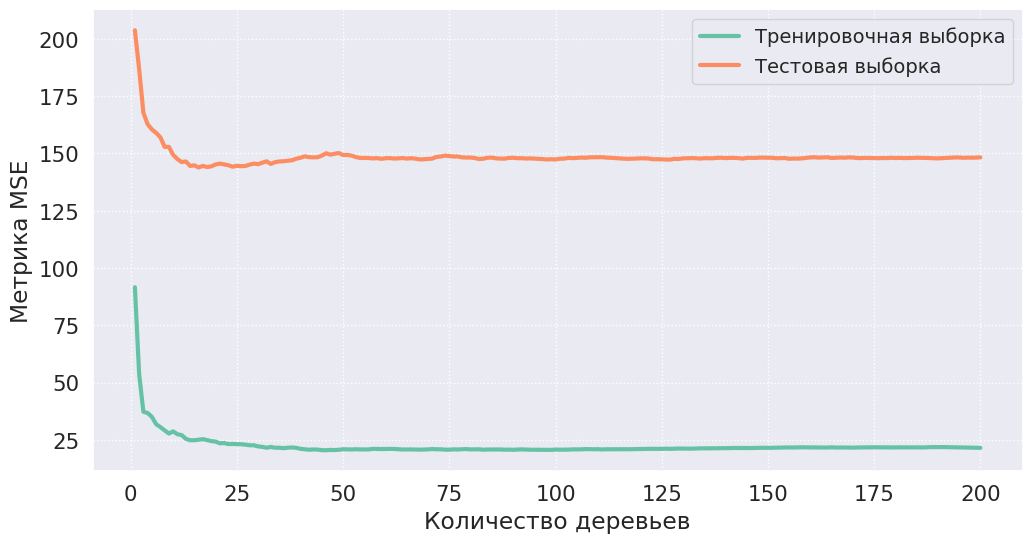

In [ ]:
cum_mse_train = cum_metric(rf, mean_squared_error, features_train, y_train)
cum_mse_test = cum_metric(rf, mean_squared_error, features_test, y_grid)
estrimator_range = np.arange(n_estimators) + 1

plot_some_lines(
    lines={
        'Тренировочная выборка': cum_mse_train,
        'Тестовая выборка': cum_mse_test,
    },
    xlabel='Количество деревьев',
    estrimator_range=estrimator_range,
    metric_name='MSE',
)

Как видим, начиная с некоторого момента ошибка на тесте начинает расти, в то время как ошибка на трейне падает. Это так же является признаком переобучения.

>**НО!** Это свойство конкретной **реализации** модели. Вспоминаем, что случайный лес это усреднение независимых одинаково распределенных случайных деревьев. Т.е. мы получили **свойство, верное для выпавшего элементарного исхода** из вероятностного пространства, что не означает его выполнение для всех других элементарных исходов.
>
> Вообще, нет никакой причины, почему случайный лес в среднем должен переобучаться с увеличением количества деревьев, ведь мы просто усредняем независимые при фиксированной выборке, одинаково распределенные деревья.


**Переставим деревья** в нашей обученной модели случайный образом.

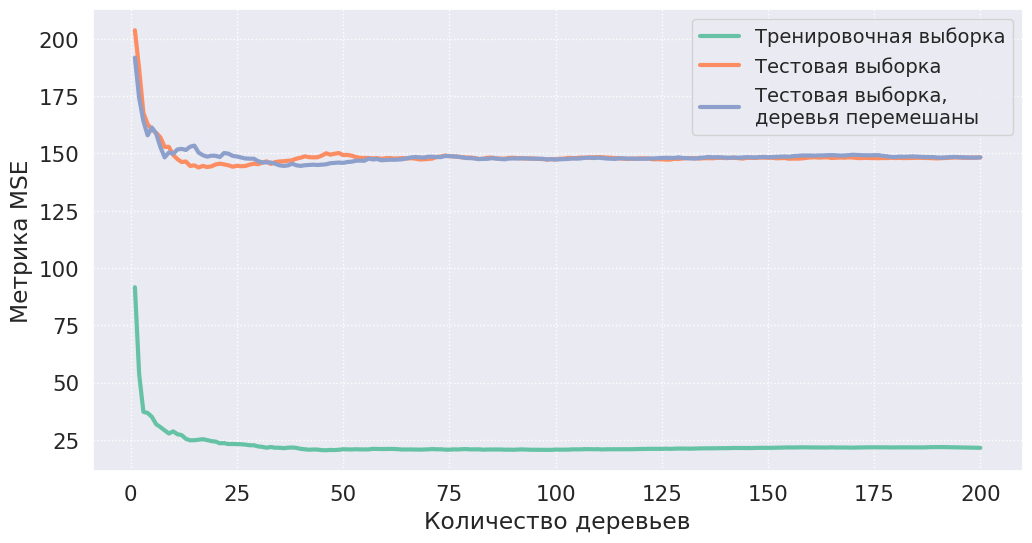

In [ ]:
cum_mse_train = cum_metric(rf, mean_squared_error, features_train, y_train)
cum_mse_test = cum_metric(rf, mean_squared_error, features_test, y_grid)
cum_mse_test_shuffle = cum_metric(
    rf, mean_squared_error, features_test, y_grid, shuffle=True
)

plot_some_lines(
    lines={
        'Тренировочная выборка': cum_mse_train,
        'Тестовая выборка': cum_mse_test,
        'Тестовая выборка,\nдеревья перемешаны': cum_mse_test_shuffle,
    },
    xlabel='Количество деревьев',
    estrimator_range=estrimator_range,
    metric_name='MSE',
)

Как видим, теперь ошибка на тесте в целом падает с ростом количества деревьев.

Чтобы лучше понять, посчитаем и визуализируем ошибку по каждом конкретному дереву.

In [ ]:
def metric_trees(
    model: RandomForestRegressor,
    metric: Callable[[np.ndarray, np.ndarray], float],
    x_test: np.ndarray,
    y_test: np.ndarray,
):
    '''
    Подсчет метрики для каждого дерева.

    Параметры:
    model (RandomForestRegressor): модель RandomForest
    metric (Callable[[np.ndarray, np.ndarray], float]): метрика
    x_test (np.ndarray): тестовая выборка
    y_test (np.ndarray): ответы на тестовой выборки

    Возвращает: массив значений метрики для каждого дерева
    '''
    predictions_by_estimators = [
        est.predict(x_test) for est in model.estimators_
    ]
    predictions_by_estimators = np.array(predictions_by_estimators)
    values = [metric(y_test, pred) for pred in predictions_by_estimators]
    return np.array(values)


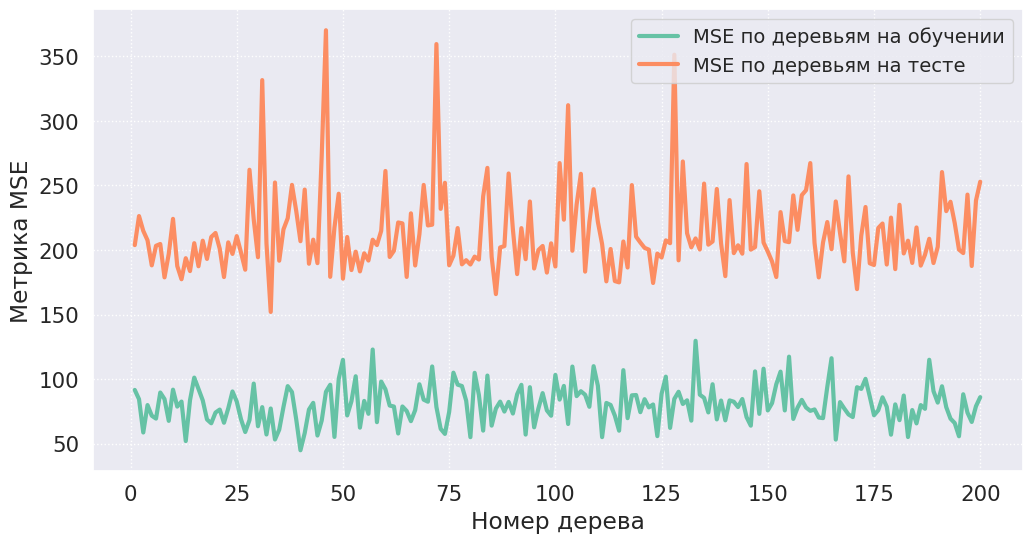

In [ ]:
trees_mse_train = metric_trees(
    rf, mean_squared_error, features_train, y_train
)
trees_mse_test = metric_trees(
    rf, mean_squared_error, features_test, y_grid
)

plot_some_lines(
    lines={
        'MSE по деревьям на обучении': trees_mse_train,
        'MSE по деревьям на тесте': trees_mse_test,
    },
    xlabel='Номер дерева',
    estrimator_range=estrimator_range,
    metric_name='MSE',
)

Как видим, звезды так совпали, что в начале идут деревья только с относительно низкой ошибкой, в следствии чего для всего леса ошибка с ростом количества деревьев возрастает.

Интересно, что будет если оставить **только "хорошие" деревья**, т.е. деревья, для которых ошибка не сильно велика. В таком случае можно получить лучшее качество композиции, но лишь немного.

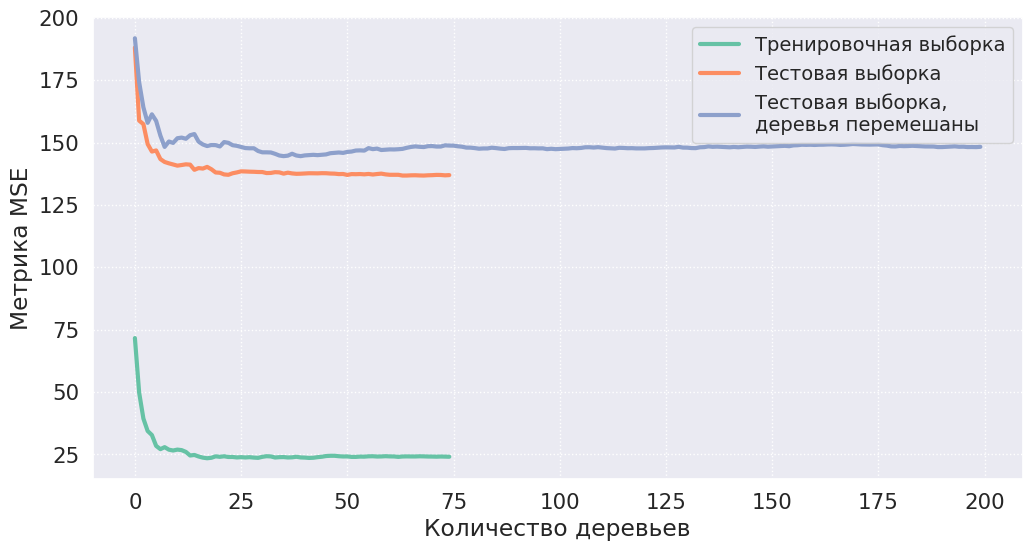

In [ ]:
rf.estimators_ = np.array(rf.estimators_)[trees_mse_test < 200]

cum_mse_train = cum_metric(rf, mean_squared_error, features_train, y_train)
cum_mse_test = cum_metric(rf, mean_squared_error, features_test, y_grid)


plot_some_lines(
    lines={
        'Тренировочная выборка': cum_mse_train,
        'Тестовая выборка': cum_mse_test,
        'Тестовая выборка,\nдеревья перемешаны': cum_mse_test_shuffle
    },
    xlabel='Количество деревьев',
    metric_name='MSE',
)


#### 4.1.2 Зависимость от количества деревьев в среднем

Если же мы будем рассматривать среднюю ошибку по всем моделям, то она будет монотонно убывать.
Получим это с помощью симуляции.
Для этого **1000 раз обучим модель случайного леса**, по каждой посчитаем кривые и усредним.

In [ ]:
n_estimators = 200  # количество деревьев
n_iterations = 1000  # сколько раз обучим случайный лес
estrimator_range = np.arange(n_estimators) + 1

# В (i, j) записана точность на j деревьях для запуска i
scores_train = np.zeros((n_iterations, n_estimators))
scores_test = np.zeros((n_iterations, n_estimators))

# На каждой итерации обучаем свой случайный лес
for i in tqdm(range(n_iterations)):
    rf = RandomForestRegressor(n_estimators=n_estimators).fit(
        features_train, y_train
    )
    # Считаем точность классификации для всех "кумулятивных" наборах поддеревьев
    scores_train[i] = cum_metric(
        rf, mean_squared_error, features_train, y_train
    )
    scores_test[i] = cum_metric(
        rf, mean_squared_error, features_test, y_grid
    )


  0%|          | 0/1000 [00:00<?, ?it/s]

На графике ниже изображено 1000 синих кривых, которые есть ошибка на трейне в засимости от количества деревьев для каждой конкретной модели. Зеленая кривая &mdash; их усреднение. Аналогично, розовые кривые &mdash; ошибка на тесте.

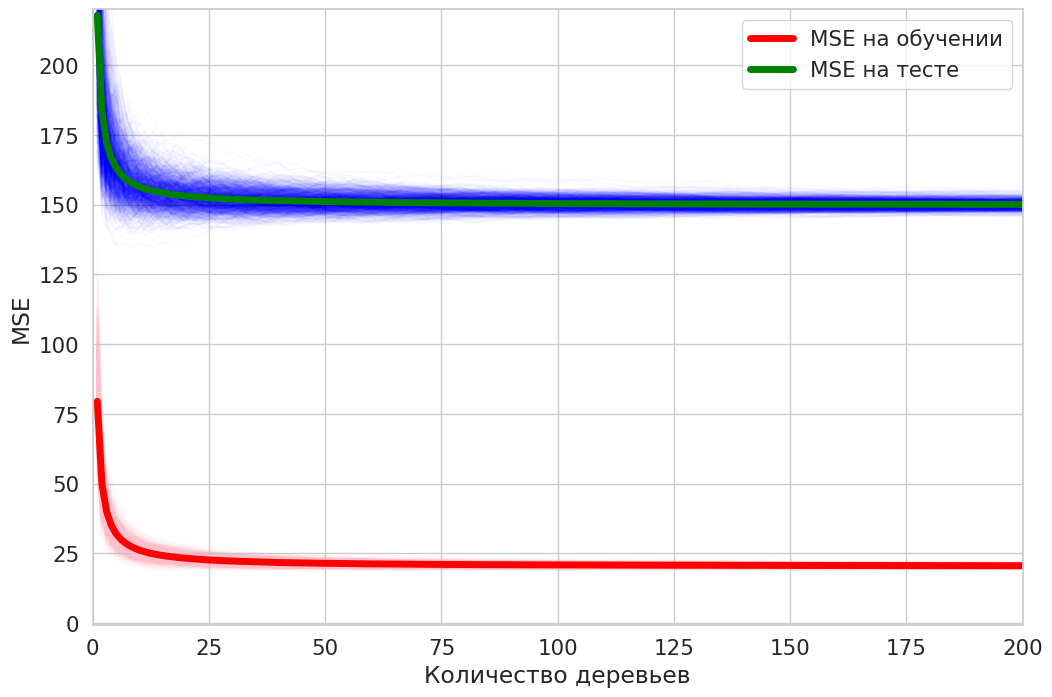

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(n_iterations):
    plt.plot(estrimator_range, scores_train[i], color='pink', alpha=0.02)
    plt.plot(estrimator_range, scores_test[i], color='blue', alpha=0.02)

plt.plot(estrimator_range, scores_train.mean(axis=0), lw=5, color='red', label='MSE на обучении')
plt.plot(estrimator_range, scores_test.mean(axis=0), lw=5, color='green', label='MSE на тесте')
plt.xlabel('Количество деревьев')
plt.ylabel('MSE')
plt.xlim((0, 200))
plt.ylim((None, 220))
plt.legend()
plt.show()

Как видно из графика, зеленые кривые монотонно убывают. Так же на графике заметен провал для некоторых синих кривых при небольшом количестве деревьев. Этот провал соответствует случаям, в которых в начале попадались только хорошие деревья. На зеленой кривой такого провала нет, поскольку есть случаи и с очень плохими деревьями.

>Отсюда можно сделать вывод про подбор оптимального количества деревьев. Подбор стоит делать только в случае рассмотрения одной конкретной реализации модели. Если же рассматривать среднюю ошибку, то она тем меньше, чем больше деревьев. Например, **бесполезно обучать модель заново на подобранное количество деревьев по одной реализации.**

>Почему же в **среднем ошибка монотонно падает**? Вспомним формулы с лекции для случая аддитивного несмещенного шума:
>$$\mathrm{bias}^2 = \left( \mathsf{E} \widehat{y}_1(x) - f(x) \right)^2,$$
>$$\mathrm{variance} = \mathsf{D} \widehat{y}_1(x) \left[ \frac{1}{T} + \frac{T-1}{T} \mathrm{corr} \left( \widehat{y}_1(x), \widehat{y}_2(x) \right) \right],$$
>где
>* $y = f(x)$ — средняя ожидаемая зависимость,
>* $T$ — количество деревьев в композиции.
>
>Как видим, bias-компонентна не меняется с увеличением количества деревьев, а variance-компонентна монотонно убывает к значению ковариации двух моделей. Они будут зависимы, т.>к. обучаются на одной выборке.
>
>Если $T$ достаточно большое, получаем
>$$\mathrm{variance} = \mathsf{D} \widehat{y}_1(x) \cdot \mathrm{corr} \left( \widehat{y}_1(x), \widehat{y}_2(x) \right).$$

#### 4.1.3 Зависимость от максимальной глубины дерева

А как качество зависит от максимальной глубины деревьев?
Для этого для каждого значения глубины обучим случайный лес на 200 деревьев 500 раз.
Посчитаем качество и построим предсказательные интервалы для значения ошибки конкретного леса, т.е. учтем как ошибку определения среднего, так и разброс конкретных реализаций.

In [ ]:
np.random.seed(RANDOM_STATE)

depths = np.arange(1, 15)
n_estimators = 200  # количество деревьев
n_iterations = 500  # сколько раз обучим случайный лес
scores_train = np.zeros((n_iterations, len(depths)))
scores_test = np.zeros((n_iterations, len(depths)))

for i in tqdm(range(n_iterations)):
    for max_depth in depths:
        rf = RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth
        ).fit(features_train, y_train)

        scores_train[i, max_depth-1] = mean_squared_error(
            y_train, rf.predict(features_train)
        )
        scores_test[i, max_depth-1] = mean_squared_error(
            y_grid, rf.predict(features_test)
        )

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
scores_train_new = scores_train.copy()
for i in range(len(depths)):
    scores_train_new[:, (i+1)%len(depths)] = scores_train[:, i]

scores_test_new = scores_test.copy()
for i in range(len(depths)):
    scores_test_new[:, (i+1)%len(depths)] = scores_test[:, i]

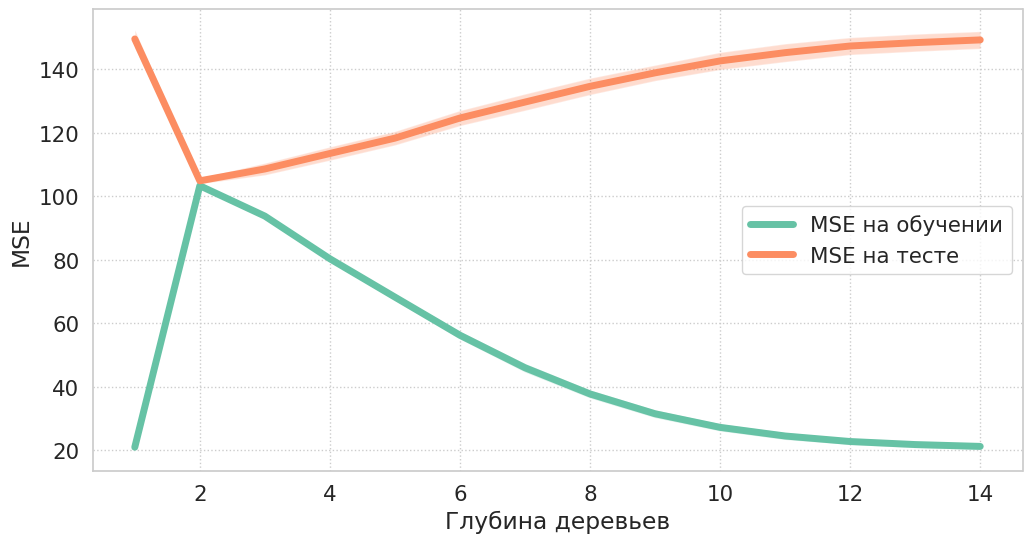

In [ ]:
plt.figure(figsize=(12, 6))
for scores, label in zip(
    [scores_train_new, scores_test_new], ['MSE на обучении', 'MSE на тесте']
):
    means = scores.mean(axis=0)
    std = scores.std(axis=0)
    deviations_value = std * 2 * np.sqrt(1 + 1 / n_iterations)
    plt.plot(depths, means, lw=5, label=label)
    plt.fill_between(
        depths, means - deviations_value, means + deviations_value, alpha=0.3
    )

plt.xlabel('Глубина деревьев')
plt.ylabel('MSE')
plt.grid(ls=':')
plt.legend()
plt.show()

Как видим, ошибка на тесте растет с увеличением разрешенной глубины, в то время как на трейне она падает.

Опимальная глубина для теста равна 2. Посмотрим на сами предсказания для этой глубины.

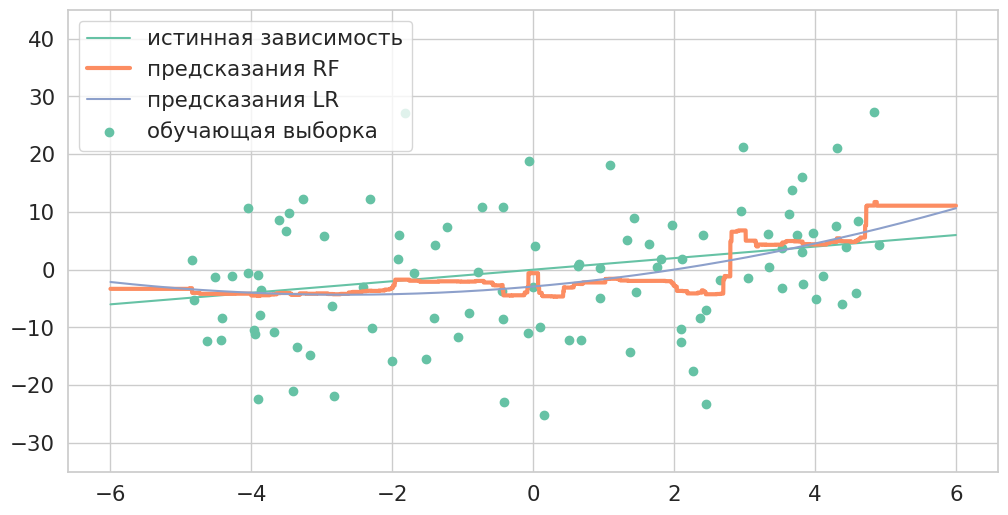

In [ ]:
rf = RandomForestRegressor(
    n_estimators=n_estimators, max_depth=2
).fit(features_train, y_train)

grid = np.arange(-6, 6, 0.001)
features_test = grid[:, np.newaxis] ** np.arange(1, poly_degree+1)
preds_rf = rf.predict(features_test)
preds_lr = lr.predict(features_test)

plt.figure(figsize=(12, 6))
plt.plot(grid, grid, label='истинная зависимость')
plt.plot(grid, preds_rf, label='предсказания RF', lw=3)
plt.plot(grid, preds_lr, label='предсказания LR')
plt.scatter(x_train, y_train, label='обучающая выборка')
plt.legend(loc=2)
plt.ylim((-35, 45))
plt.show()

Предсказания выглядят лучше, чем было в самом начале: видно, что модель не переобучена.

### 4.2 Не сильно шумные данные

Наконец, посмотрим, как зависит ошибка от глубины деревьев в случае если данные не сильно шумные. Для этого поставим стандартное отклонение шума равным 2, что гораздо меньше 10 из предыдущего случая.

In [ ]:
np.random.seed(RANDOM_STATE)

train_size = 100  # размер обучающей выборки
poly_degree = 2  # максимальная степень полинома
noise_scale = 2  # станд. отклонение шума
n_estimators = 200  # количество деревьев

x_train = sps.uniform(loc=-5, scale=10).rvs(size=(train_size, 1))
y_train = x_train.ravel() + sps.norm(scale=noise_scale).rvs(size=train_size)
features_train = x_train ** np.arange(1, poly_degree+1)

rf = RandomForestRegressor(
    n_estimators=n_estimators
).fit(
    features_train, y_train
)
lr = LinearRegression().fit(features_train, y_train)

In [ ]:
depths = np.arange(1, 15)
n_estimators = 200  # количество деревьев
n_iterations = 500  # сколько раз обучим случайный лес
scores_train = np.zeros((n_iterations, len(depths)))
scores_test = np.zeros((n_iterations, len(depths)))

for i in tqdm(range(n_iterations)):
    for max_depth in depths:
        rf = RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth
        ).fit(features_train, y_train)

        scores_train[i, max_depth-1] = mean_squared_error(
            y_train, rf.predict(features_train)
        )
        scores_test[i, max_depth-1] = mean_squared_error(
            y_grid, rf.predict(features_test)
        )

  0%|          | 0/500 [00:00<?, ?it/s]

Как видим из графика, от глубины почти ничего не зависит.

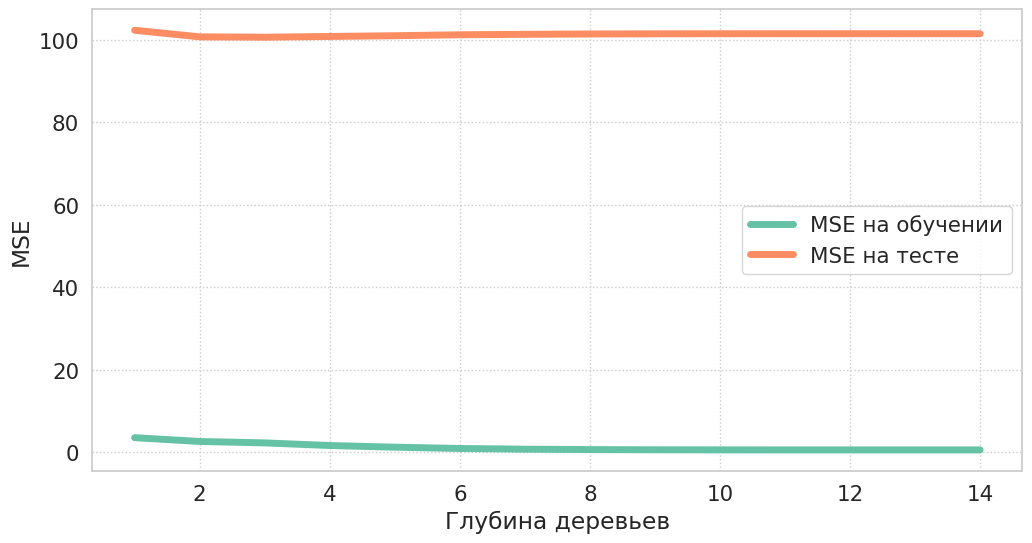

In [ ]:
plt.figure(figsize=(12, 6))
for scores, label in zip(
    [scores_train, scores_test], ['MSE на обучении', 'MSE на тесте']
):
    means = scores.mean(axis=0)
    std = scores.std(axis=0)
    deviations_value = std * 2 * np.sqrt(1 + 1 / n_iterations)
    plt.plot(depths, means, lw=5, label=label)
    plt.fill_between(
        depths, means - deviations_value, means + deviations_value, alpha=0.3
    )

plt.xlabel('Глубина деревьев')
plt.ylabel('MSE')
plt.grid(ls=':')
plt.legend()
plt.show()

Таким образом, **глубину деревьев в случайном лесе имеет смысл подбирать только для очень шумных данных.**

**Общие выводы**

В ходе этого ноутбука мы детально изучили алгоритм **случайного леса** и его применение для задач регрессии и классификации. На основе проведённых экспериментов можно сделать следующие ключевые выводы:

1.  **Превосходство над простыми моделями**: Мы увидели, что простые модели, такие как **линейная регрессия**, неспособны улавливать сложные нелинейные зависимости в данных. В то же время, одно **решающее дерево**, хотя и может аппроксимировать сложные функции, сталкивается с дилеммой: неглубокие деревья оказываются слишком грубыми и недообучаются, а глубокие — крайне склонны к переобучению, подстраиваясь под шум в обучающей выборке.

2.  **Сила случайного леса**: Случайный лес эффективно решает проблему переобучения, свойственную одиночным деревьям. Ключевая идея заключается в **ансамблировании**: создаётся множество разнообразных деревьев (за счёт обучения на случайных подвыборках данных и признаков), и их предсказания усредняются. Этот подход позволяет:
    * **Снизить дисперсию**: Усреднение "сглаживает" ошибки и шумовые зависимости, которые выучило каждое отдельное дерево.
    * **Повысить обобщающую способность**: Итоговая модель становится более робастной и показывает значительно лучшее качество на тестовых данных.

3.  **Интерпретируемость и важность признаков**: Несмотря на свою сложность, случайный лес предоставляет удобный инструмент для анализа данных — **важность признаков** (`feature_importances_`).

4.  **Настройка гиперпараметров**: Мы выяснили, что производительность модели зависит от её гиперпараметров. Например, увеличение количества деревьев (`n_estimators`) улучшает качество до определённого предела, после которого качество стабилизируется и меняется только скорость работы. А каждое дерево в отдельности лучше делать более сложным и переобученным, увеличивая `max_depth` и уменьшая `min_samples_leaf` и `min_samples_split`.

Таким образом, **случайный лес** представляет собой мощный, универсальный и относительно устойчивый к переобучению алгоритм.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока